#### **World Cup Match Outcome: Multiclass Modeling Pipeline**

| Part | Sections | Content |
|---|---|---|
| **I** | 1–3 | Feature engineering: team-level, player/squad, match assembly |
| **II** | 4–6 | Model configs, training, core results |
| **III** | 7–9 | Bootstrap uncertainty, temporal leakage audit, consolidated validation |
| **IV** | 10–11 | SHAP feature importance, algorithm sensitivity |

#### **Setup**

In [ ]:
import warnings

warnings.filterwarnings("ignore")

import json
import os
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image as IPyImage, display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize
import xgboost as xgb
import shap

try:
    import lime
    import lime.lime_tabular

    HAS_LIME = True
except ImportError:
    print("LIME not installed: pip install lime")
    HAS_LIME = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

# ── Paths ──
BASE = Path("../../")  # repo root
DB_PATH = BASE / "data/raw/worldcup/data-sqlite/worldcup.db"
ELO_PATH = BASE / "data/raw/elo_ratings.csv"
FIFA_PATH = BASE / "data/raw/fifa_ranking-2024-06-20.csv"
PLAYER_PATH = BASE / "data/processed/player_stats_with_club_elo.csv"
OUT_DIR = Path("./data")
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = BASE / "docs/figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_and_display_fig(fig, filename, dpi=180):
    path = FIG_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    display(IPyImage(filename=str(path)))
    print(f"Saved figure: {path}")
    return path


for p in [DB_PATH, ELO_PATH, FIFA_PATH, PLAYER_PATH]:
    assert p.is_file(), f"Not found: {p}"

SEED = 42
HOLDOUT_YEARS = [2018, 2022]
CLASS_LABELS = ["fav_loses", "draw", "fav_wins"]
BOOTSTRAP_B = 5000
ALPHA, BETA = 2.0, 2.0

print("All paths OK.")

All paths OK.


In [2]:
con = sqlite3.connect(DB_PATH)


def _sql(q):
    return pd.read_sql_query(q, con)


matches = _sql("SELECT * FROM matches")
tournaments = _sql("SELECT * FROM tournaments")
teams = _sql("SELECT * FROM teams")
team_appearances = _sql("SELECT * FROM team_appearances")
squads = _sql("SELECT * FROM squads")
players = _sql("SELECT * FROM players")
manager_appointments = _sql("SELECT * FROM manager_appointments")
managers = _sql("SELECT * FROM managers")
manager_appearances = _sql("SELECT * FROM manager_appearances")
con.close()

tournaments["start_dt"] = pd.to_datetime(
    tournaments["start_date"], unit="D", origin="unix", errors="coerce"
)
matches["match_dt"] = pd.to_datetime(
    matches["match_date"], unit="D", origin="unix", errors="coerce"
)
tourn_meta = tournaments[
    ["tournament_id", "tournament_name", "year", "host_country", "start_dt"]
].copy()

# Men's WC only
men_ids = tourn_meta.loc[
    ~tourn_meta["tournament_name"].str.contains("Women", case=False, na=False),
    "tournament_id",
].unique()
matches = matches[matches["tournament_id"].isin(men_ids)].copy()
team_appearances = team_appearances[
    team_appearances["tournament_id"].isin(men_ids)
].copy()

ta_hist = team_appearances.merge(
    tourn_meta[["tournament_id", "year"]], on="tournament_id", how="left"
).merge(
    matches[["match_id", "knockout_stage", "group_stage"]],
    on="match_id",
    how="left",
    suffixes=("", "_m"),
)
team_tourn = (
    team_appearances[["tournament_id", "team_id"]]
    .drop_duplicates()
    .merge(tourn_meta[["tournament_id", "year"]], on="tournament_id", how="left")
)
print(f"men's WC matches: {matches.shape[0]}, team×tournament: {team_tourn.shape[0]}")

men's WC matches: 964, team×tournament: 489


#### **Part I - Feature Engineering**

##### **Section 1 - Team-Level Features**

- One row per `(tournament_id, team_id)` . 

- Features: historical WC performance (Laplace-smoothed), squad demographics, manager attributes, Elo, and FIFA ranking.

In [3]:
def shrink(w, n, a=ALPHA, b=BETA):
    return (w + a) / (n + a + b)


def prior_team_stats(team_id, before_year):
    sub = ta_hist[(ta_hist["team_id"] == team_id) & (ta_hist["year"] < before_year)]
    if sub.empty:
        return dict(
            hist_n_tournaments=0,
            hist_n_matches=0,
            hist_wins=0,
            hist_draws=0,
            hist_losses=0,
            hist_goal_diff_sum=0,
            hist_ko_matches=0,
            hist_ko_wins=0,
            hist_pso_matches=0,
            hist_pso_wins=0,
            hist_et_matches=0,
            hist_tournaments_with_ko_game=0,
        )
    ko = sub[sub["knockout_stage"] == 1]
    pso = sub[sub["penalty_shootout"] == 1]
    return dict(
        hist_n_tournaments=sub["tournament_id"].nunique(),
        hist_n_matches=len(sub),
        hist_wins=int(sub["win"].sum()),
        hist_draws=int(sub["draw"].sum()),
        hist_losses=int(sub["lose"].sum()),
        hist_goal_diff_sum=float((sub["goals_for"] - sub["goals_against"]).sum()),
        hist_ko_matches=len(ko),
        hist_ko_wins=int(ko["win"].sum()),
        hist_pso_matches=len(pso),
        hist_pso_wins=int((pso["penalties_for"] > pso["penalties_against"]).sum()),
        hist_et_matches=int(sub["extra_time"].sum()),
        hist_tournaments_with_ko_game=len(set(ko["tournament_id"].unique())),
    )


years_all = sorted(team_tourn["year"].dropna().unique())
all_tids = team_tourn["team_id"].unique()
hist_cache = {
    (tid, int(y)): prior_team_stats(tid, int(y)) for tid in all_tids for y in years_all
}

hist_rows = []
for _, row in team_tourn.iterrows():
    key = (row["team_id"], int(row["year"]))
    h = hist_cache[key]
    n, w = h["hist_n_matches"], h["hist_wins"]
    km, kw = h["hist_ko_matches"], h["hist_ko_wins"]
    pm, pw = h["hist_pso_matches"], h["hist_pso_wins"]
    hist_rows.append(
        {
            "tournament_id": row["tournament_id"],
            "team_id": row["team_id"],
            "year": row["year"],
            **h,
            "hist_win_rate_shrunk": shrink(w, n),
            "hist_draw_rate_shrunk": shrink(h["hist_draws"], n),
            "hist_goal_diff_per_match": (
                h["hist_goal_diff_sum"] / n if n > 0 else np.nan
            ),
            "hist_ko_win_rate_shrunk": shrink(kw, km),
            "hist_pso_win_rate_shrunk": shrink(pw, pm) if pm > 0 else np.nan,
            "hist_et_rate": h["hist_et_matches"] / n if n > 0 else np.nan,
            "hist_frac_ko": (
                h["hist_tournaments_with_ko_game"] / h["hist_n_tournaments"]
                if h["hist_n_tournaments"] > 0
                else np.nan
            ),
        }
    )
hist_df = pd.DataFrame(hist_rows)
print(f"hist_df: {hist_df.shape}")

hist_df: (489, 22)


In [4]:
# Squad demographics & WC experience
sq = squads.merge(tourn_meta[["tournament_id", "year", "start_dt"]], on="tournament_id")
sq = sq[sq["tournament_id"].isin(men_ids)].copy()
sq = sq.merge(players, on="player_id", how="left")
sq["birth_dt"] = pd.to_datetime(sq["birth_date"], errors="coerce")
sq["age_at_tournament"] = (sq["start_dt"] - sq["birth_dt"]).dt.days / 365.25
for col in ["goal_keeper", "defender", "midfielder", "forward"]:
    sq[col] = sq[col].fillna(0).astype(int)

pyt = sq[["player_id", "tournament_id", "year"]].drop_duplicates()
prior_rows = []
for (pid, y), g in pyt.groupby(["player_id", "year"]):
    n_prior = pyt[(pyt["player_id"] == pid) & (pyt["year"] < y)][
        "tournament_id"
    ].nunique()
    prior_rows.append({"player_id": pid, "year": y, "prior_wc_played": n_prior})
sq = sq.merge(pd.DataFrame(prior_rows), on=["player_id", "year"], how="left")

squad_records = []
for (tid, tmid), g in sq.groupby(["tournament_id", "team_id"]):
    squad_records.append(
        dict(
            tournament_id=tid,
            team_id=tmid,
            squad_n_players=len(g),
            squad_age_mean=g["age_at_tournament"].mean(),
            squad_age_median=g["age_at_tournament"].median(),
            squad_age_std=g["age_at_tournament"].std(),
            squad_age_min=g["age_at_tournament"].min(),
            squad_age_max=g["age_at_tournament"].max(),
            squad_n_gk=int(g["goal_keeper"].sum()),
            squad_n_df=int(g["defender"].sum()),
            squad_n_mf=int(g["midfielder"].sum()),
            squad_n_fw=int(g["forward"].sum()),
            squad_prior_wc_mean=g["prior_wc_played"].mean(),
            squad_prior_wc_median=g["prior_wc_played"].median(),
            squad_share_any_prior_wc=(g["prior_wc_played"] > 0).mean(),
            squad_share_ge2_prior_wc=(g["prior_wc_played"] >= 2).mean(),
        )
    )
squad_df = pd.DataFrame(squad_records)

# Jaccard squad continuity vs previous WC
overlap_rows = []
for team_id, g in sq.groupby("team_id"):
    g = g.sort_values("year")
    years_order = sorted(g["year"].unique())
    prev_players = None
    for y in years_order:
        cur = set(g.loc[g["year"] == y, "player_id"].unique())
        tid = g.loc[g["year"] == y, "tournament_id"].iloc[0]
        if prev_players is not None:
            inter = len(cur & prev_players)
            uni = len(cur | prev_players)
            overlap_rows.append(
                dict(
                    tournament_id=tid,
                    team_id=team_id,
                    squad_jaccard_vs_prev_wc=inter / uni if uni else np.nan,
                    squad_overlap_count_vs_prev_wc=inter,
                )
            )
        prev_players = cur
squad_df = squad_df.merge(
    pd.DataFrame(overlap_rows), on=["tournament_id", "team_id"], how="left"
)
print(f"squad_df: {squad_df.shape}")

squad_df: (489, 18)


In [5]:
# Manager / coach features
ma = manager_appointments.merge(
    tourn_meta[["tournament_id", "year"]], on="tournament_id"
).merge(managers, on="manager_id", how="left")
ma = ma[ma["tournament_id"].isin(men_ids)].copy()
ma_pick = ma.sort_values("manager_id").drop_duplicates(
    subset=["tournament_id", "team_id"], keep="first"
)


def _norm(s):
    return s.astype(str).str.strip().str.lower().str.replace(" ", "", regex=False)


team_name_map_str = teams.set_index("team_id")["team_name"].to_dict()
ma_pick["team_name"] = ma_pick["team_id"].map(team_name_map_str)
ma_pick["manager_local"] = (
    _norm(ma_pick["country_name"]) == _norm(ma_pick["team_name"])
).astype(int)

mgr_tourneys = (
    ma_pick[["manager_id", "tournament_id", "year"]]
    .drop_duplicates()
    .sort_values(["manager_id", "year"])
)
mgr_prior_rows = []
for mid, g in mgr_tourneys.groupby("manager_id"):
    for i, (_, r) in enumerate(g.iterrows()):
        mgr_prior_rows.append(
            {
                "manager_id": mid,
                "tournament_id": r["tournament_id"],
                "mgr_n_prior_wc": i,
            }
        )
mgr_prior_df = pd.DataFrame(mgr_prior_rows)

streak_rows = []
for (mid, tid), g in ma_pick.sort_values("year").groupby(["manager_id", "team_id"]):
    g = g.drop_duplicates(subset=["tournament_id", "year"]).sort_values("year")
    yrs = g["year"].astype(int).tolist()
    tids = g["tournament_id"].tolist()
    run = 0
    for i, y in enumerate(yrs):
        run = (run + 1) if (i == 0 or y - yrs[i - 1] in (1, 4)) else 1
        streak_rows.append(
            {
                "manager_id": mid,
                "team_id": tid,
                "tournament_id": tids[i],
                "mgr_consecutive_wc_with_team": run,
            }
        )
streak_df = pd.DataFrame(streak_rows)

mapp = manager_appearances.merge(
    tourn_meta[["tournament_id", "year"]], on="tournament_id"
).merge(
    team_appearances[["tournament_id", "match_id", "team_id", "win"]],
    on=["tournament_id", "match_id", "team_id"],
    how="left",
)
mapp = mapp[mapp["tournament_id"].isin(men_ids)].copy()

mgr_hist_rows = []
for mid, g in mapp.groupby("manager_id"):
    g = g.sort_values("year")
    for y in g["year"].unique():
        sub = g[g["year"] < y].dropna(subset=["win"])
        mgr_hist_rows.append(
            {
                "manager_id": mid,
                "year": y,
                "mgr_hist_win_rate_shrunk": shrink(int(sub["win"].sum()), len(sub)),
            }
        )
mgr_hist_df = pd.DataFrame(mgr_hist_rows).drop_duplicates(["manager_id", "year"])

coach_df = (
    ma_pick[["tournament_id", "team_id", "manager_id", "manager_local", "year"]]
    .merge(mgr_prior_df, on=["manager_id", "tournament_id"], how="left")
    .merge(
        streak_df[
            ["manager_id", "team_id", "tournament_id", "mgr_consecutive_wc_with_team"]
        ],
        on=["manager_id", "team_id", "tournament_id"],
        how="left",
    )
    .merge(mgr_hist_df, on=["manager_id", "year"], how="left")
)[
    [
        "tournament_id",
        "team_id",
        "manager_local",
        "mgr_n_prior_wc",
        "mgr_consecutive_wc_with_team",
        "mgr_hist_win_rate_shrunk",
    ]
]
print(f"coach_df: {coach_df.shape}")

coach_df: (489, 6)


In [6]:
# Elo rating (pre-tournament snapshot)
def _norm_str(s):
    return str(s).strip().lower().replace(" ", "")


elo_raw = pd.read_csv(ELO_PATH)
elo_wc = elo_raw.rename(
    columns={"team": "elo_team_name", "rating": "elo_rating", "rank": "elo_rank"}
)
elo_wc["_name_norm"] = elo_wc["elo_team_name"].apply(_norm_str)

team_names_df = teams[["team_id", "team_name", "team_code"]].copy()
team_names_df["_name_norm"] = team_names_df["team_name"].apply(_norm_str)

elo_lookup = elo_wc[["year", "_name_norm", "elo_rating", "elo_rank"]].copy()
elo_lookup["year"] = elo_lookup["year"].astype(int)

elo_rows = []
for _, row in team_tourn.iterrows():
    y = int(row["year"])
    tid = row["team_id"]
    tname_norm = team_names_df.loc[team_names_df["team_id"] == tid, "_name_norm"].values
    if len(tname_norm) == 0:
        elo_rows.append(
            {
                "tournament_id": row["tournament_id"],
                "team_id": tid,
                "elo_rating": np.nan,
                "elo_rank": np.nan,
            }
        )
        continue
    tname_norm = tname_norm[0]
    match = elo_lookup[
        (elo_lookup["year"] == y) & (elo_lookup["_name_norm"] == tname_norm)
    ]
    if match.empty:
        match = elo_lookup[
            (elo_lookup["year"] == y - 1) & (elo_lookup["_name_norm"] == tname_norm)
        ]
    if not match.empty:
        elo_rows.append(
            {
                "tournament_id": row["tournament_id"],
                "team_id": tid,
                "elo_rating": match.iloc[0]["elo_rating"],
                "elo_rank": match.iloc[0]["elo_rank"],
            }
        )
    else:
        elo_rows.append(
            {
                "tournament_id": row["tournament_id"],
                "team_id": tid,
                "elo_rating": np.nan,
                "elo_rank": np.nan,
            }
        )
elo_df = pd.DataFrame(elo_rows)
print(f"Elo coverage: {elo_df['elo_rating'].notna().mean():.1%}")

Elo coverage: 99.2%


In [7]:
# FIFA ranking (pre-tournament snapshot)
FIFA_NAME_MAP = {
    "iriran": "iran",
    "korearepublic": "southkorea",
    "koreadpr": "northkorea",
    "usa": "unitedstates",
    "côted'ivoire": "ivorycoast",
    "coted'ivoire": "ivorycoast",
    "czechia": "czechrepublic",
    "türkiye": "turkey",
    "turkiye": "turkey",
    "chinapr": "china",
    "trinidadtobago": "trinidadandtobago",
    "trinidad&tobago": "trinidadandtobago",
}


def _fifa_norm(s):
    n = _norm_str(s)
    return FIFA_NAME_MAP.get(n, n)


fifa_raw = pd.read_csv(FIFA_PATH, parse_dates=["rank_date"])
fifa_raw["_name_norm"] = fifa_raw["country_full"].apply(_fifa_norm)

WC_START = {
    1994: "1994-06-17",
    1998: "1998-06-10",
    2002: "2002-05-31",
    2006: "2006-06-09",
    2010: "2010-06-11",
    2014: "2014-06-12",
    2018: "2018-06-14",
    2022: "2022-11-20",
}
WC_START = {k: pd.Timestamp(v) for k, v in WC_START.items()}

fifa_rows = []
for _, row in team_tourn.iterrows():
    y = int(row["year"])
    tid = row["team_id"]
    cutoff = WC_START.get(y)
    tname_norm = team_names_df.loc[team_names_df["team_id"] == tid, "_name_norm"].values
    if cutoff is None or len(tname_norm) == 0:
        fifa_rows.append(
            {
                "tournament_id": row["tournament_id"],
                "team_id": tid,
                "fifa_rank": np.nan,
                "fifa_points": np.nan,
            }
        )
        continue
    snap = fifa_raw[
        (fifa_raw["rank_date"] <= cutoff) & (fifa_raw["_name_norm"] == tname_norm[0])
    ]
    if snap.empty:
        fifa_rows.append(
            {
                "tournament_id": row["tournament_id"],
                "team_id": tid,
                "fifa_rank": np.nan,
                "fifa_points": np.nan,
            }
        )
    else:
        best = snap.sort_values("rank_date").iloc[-1]
        fifa_rows.append(
            {
                "tournament_id": row["tournament_id"],
                "team_id": tid,
                "fifa_rank": best.get("rank", np.nan),
                "fifa_points": best.get("total_points", np.nan),
            }
        )
fifa_df = pd.DataFrame(fifa_rows)
print(f"FIFA coverage: {fifa_df['fifa_rank'].notna().mean():.1%}")

FIFA coverage: 50.7%


In [8]:
# Merge all team features
feat_team = (
    hist_df.merge(squad_df, on=["tournament_id", "team_id"], how="left")
    .merge(coach_df, on=["tournament_id", "team_id"], how="left")
    .merge(elo_df, on=["tournament_id", "team_id"], how="left")
    .merge(fifa_df, on=["tournament_id", "team_id"], how="left")
    .merge(
        teams[["team_id", "confederation_id", "team_name", "team_code"]],
        on="team_id",
        how="left",
    )
)
print(f"feat_team: {feat_team.shape}")
display(
    feat_team[feat_team["year"] == 2022][
        [
            "team_name",
            "elo_rating",
            "hist_win_rate_shrunk",
            "squad_age_mean",
            "fifa_rank",
        ]
    ].head()
)

feat_team: (489, 49)


,team_name,elo_rating,hist_win_rate_shrunk,squad_age_mean,fifa_rank
457,Qatar,1578.0,0.500000,27.526141,50.0
458,Ecuador,1842.0,0.428571,26.067393,44.0
459,England,1967.0,0.438356,26.963197,5.0
460,Iran,1779.0,0.210526,29.419849,20.0
461,Senegal,1747.0,0.416667,26.462170,18.0


##### **Section 2 - Player & Squad Features**

- One row per `(tournament_id, team_id)` built from club-season data (2006–2022 only). 

- Features: shrinkage-adjusted per-appearance rates, Elo-weighted volume, positional club strength, squad cohesion, and WC pedigree.

In [9]:
df_pl = pd.read_csv(PLAYER_PATH)
if "team_name" in df_pl.columns and "national_team" not in df_pl.columns:
    df_pl = df_pl.rename(columns={"team_name": "national_team"})
if "goals" in df_pl.columns and "club_goals" not in df_pl.columns:
    df_pl = df_pl.rename(columns={"goals": "club_goals"})

active = df_pl[df_pl["perf_found"] == True].copy()
active["goals_per_app"] = active["club_goals"] / active["appearances"].replace(
    0, np.nan
)
active["assists_per_app"] = active["assists"] / active["appearances"].replace(0, np.nan)

MIN_APP = 10
for rate_col, _ in [("goals_per_app", "club_goals"), ("assists_per_app", "assists")]:
    pos_median = active.groupby("position_code")[rate_col].transform("median")
    w_obs = active["appearances"].clip(upper=MIN_APP)
    w_prior = MIN_APP - w_obs
    active[rate_col + "_adj"] = (
        w_obs * active[rate_col].fillna(0) + w_prior * pos_median.fillna(0)
    ) / MIN_APP

mean_strength = active["club_strength"].mean()
active["elo_weight"] = active["club_strength"].fillna(mean_strength) / mean_strength
active["goals_elo_wt"] = active["club_goals"] * active["elo_weight"]
active["assists_elo_wt"] = active["assists"] * active["elo_weight"]


def wmean(group, col, w_col="appearances"):
    g = group.dropna(subset=[col, w_col])
    ws = g[w_col].clip(lower=0)
    if ws.sum() == 0 or len(g) == 0:
        return np.nan
    return float(np.average(g[col], weights=ws))


player_rows = []
for (wc_tid, nat_team), grp in active.groupby(["tournament_id", "national_team"]):
    row = {"tournament_id": wc_tid, "national_team": nat_team}
    for pos in ["FW", "MF", "DF"]:
        pg = grp[grp["position_code"] == pos]
        row[f"pl_{pos}_avg_strength"] = (
            pg["club_strength"].mean() if len(pg) > 0 else np.nan
        )
    row["pl_squad_goals_adj"] = wmean(grp, "goals_per_app_adj")
    row["pl_squad_assists_adj"] = wmean(grp, "assists_per_app_adj")
    fw = grp[grp["position_code"] == "FW"]
    mf = grp[grp["position_code"] == "MF"]
    row["pl_FW_goals_adj"] = wmean(fw, "goals_per_app_adj") if len(fw) > 0 else np.nan
    row["pl_MF_assists_adj"] = (
        wmean(mf, "assists_per_app_adj") if len(mf) > 0 else np.nan
    )
    row["pl_squad_goals_elo_wt"] = grp["goals_elo_wt"].sum()
    row["pl_squad_assists_elo_wt"] = grp["assists_elo_wt"].sum()
    row["pl_FW_goals_elo_wt"] = grp[grp["position_code"] == "FW"]["goals_elo_wt"].sum()
    row["pl_MF_assists_elo_wt"] = grp[grp["position_code"] == "MF"][
        "assists_elo_wt"
    ].sum()
    row["pl_squad_avg_strength"] = grp["club_strength"].mean()
    off = grp[grp["position_code"].isin(["FW", "MF"])]
    g_off = wmean(off, "goals_per_app_adj")
    a_off = wmean(off, "assists_per_app_adj")
    row["pl_offensive_score"] = (
        (g_off + a_off) if (g_off is not np.nan and a_off is not np.nan) else np.nan
    )
    gk = grp[grp["position_code"] == "GK"]
    if len(gk) > 0 and "clean_sheets" in gk.columns:
        total_app = gk["appearances"].sum()
        row["pl_GK_clean_sheet_rate"] = (
            gk["clean_sheets"].sum() / total_app if total_app > 0 else np.nan
        )
    else:
        row["pl_GK_clean_sheet_rate"] = np.nan
    if "club_league_position" in grp.columns:
        row["pl_avg_club_position"] = grp["club_league_position"].mean()
    player_rows.append(row)
player_agg = pd.DataFrame(player_rows)
print(f"player_agg: {player_agg.shape}")

player_agg: (158, 16)


In [10]:
# Club cohesion
club_col = "club_name" if "club_name" in df_pl.columns else None
cohesion_rows = []
if club_col:
    for (wc_tid, nat_team), grp in df_pl.groupby(["tournament_id", "national_team"]):
        grp_valid = grp[grp[club_col].notna() & (grp[club_col] != "")]
        club_counts = grp_valid.groupby(club_col).size()
        pairs = int((club_counts * (club_counts - 1) / 2).sum())
        largest = int(club_counts.max()) if len(club_counts) > 0 else 0
        cohesion_rows.append(
            {
                "tournament_id": wc_tid,
                "national_team": nat_team,
                "sq_club_pairs": pairs,
                "sq_largest_club_block": largest,
            }
        )
cohesion_df = pd.DataFrame(cohesion_rows)

# WC pedigree & defending champion
WC_YEAR_MAP = {
    "WC-2006": 2006,
    "WC-2010": 2010,
    "WC-2014": 2014,
    "WC-2018": 2018,
    "WC-2022": 2022,
}
con2 = sqlite3.connect(DB_PATH)
ta_all = pd.read_sql_query("SELECT * FROM team_appearances", con2)
tourn_all = pd.read_sql_query(
    "SELECT tournament_id, tournament_name, year FROM tournaments", con2
)
matches_all = pd.read_sql_query(
    "SELECT match_id, tournament_id, stage_name FROM matches", con2
)
con2.close()

_men_ids = tourn_all.loc[
    ~tourn_all["tournament_name"].str.contains("Women", case=False, na=False),
    "tournament_id",
].unique()
ta_men = ta_all[ta_all["tournament_id"].isin(_men_ids)].merge(
    tourn_all[["tournament_id", "year"]], on="tournament_id", how="left"
)

finals = matches_all[
    matches_all["stage_name"].str.lower().str.contains("final", na=False)
]
finals = finals[
    ~finals["stage_name"].str.lower().str.contains("semi|third|quarter", na=False)
]
final_winners = ta_men[
    ta_men["match_id"].isin(finals["match_id"]) & (ta_men["win"] == 1)
][["tournament_id", "team_id", "year"]].drop_duplicates()
year_to_winner = final_winners.set_index("year")["team_id"].to_dict()
DEFENDING_MAP = {y + 4: tid for y, tid in year_to_winner.items()}
DEFENDING_MAP.update(
    {2006: "T-11", 2010: "T-53", 2014: "T-52", 2018: "T-33", 2022: "T-32"}
)

stage_order = {
    "group stage": 0,
    "round of 16": 1,
    "round of sixteen": 1,
    "quarter-finals": 2,
    "quarter-final": 2,
    "semi-finals": 3,
    "semi-final": 3,
    "third-place match": 3,
    "third place match": 3,
    "final": 4,
}
ta_men_stage = ta_men.merge(
    matches_all[["match_id", "stage_name"]], on="match_id", how="left"
)
ta_men_stage["stage_val"] = (
    ta_men_stage["stage_name"].str.lower().map(stage_order).fillna(0)
)
team_reach = (
    ta_men_stage.groupby(["tournament_id", "team_id", "year"])["stage_val"]
    .max()
    .reset_index(name="best_stage")
)
team_wins = (
    ta_men.groupby(["tournament_id", "team_id", "year"])["win"]
    .sum()
    .reset_index(name="tourn_wins")
)
team_tourn_hist = team_reach.merge(team_wins, on=["tournament_id", "team_id", "year"])

pedigree_rows = []
all_team_ids_ped = team_tourn_hist["team_id"].unique()
for wc_tid, wc_year in WC_YEAR_MAP.items():
    for tid in all_team_ids_ped:
        prior = team_tourn_hist[
            (team_tourn_hist["team_id"] == tid) & (team_tourn_hist["year"] < wc_year)
        ]
        pedigree_rows.append(
            dict(
                tournament_id=wc_tid,
                team_id=tid,
                sq_wc_appearances=len(prior),
                sq_wc_total_wins=int(prior["tourn_wins"].sum()),
                sq_wc_finals=(prior["best_stage"] == 4).sum(),
                sq_wc_semis=(prior["best_stage"] >= 3).sum(),
                sq_defending_champion=int(DEFENDING_MAP.get(wc_year) == tid),
            )
        )
pedigree_df = pd.DataFrame(pedigree_rows)

# Merge player features
if "team_id" in df_pl.columns:
    name_to_id = df_pl[["tournament_id", "national_team", "team_id"]].drop_duplicates()
else:
    con3 = sqlite3.connect(DB_PATH)
    teams_db_pl = pd.read_sql_query("SELECT team_id, team_name FROM teams", con3)
    con3.close()
    name_to_id = player_agg[["tournament_id", "national_team"]].drop_duplicates()
    name_to_id = name_to_id.merge(
        teams_db_pl.rename(columns={"team_name": "national_team"}),
        on="national_team",
        how="left",
    )

player_agg = player_agg.merge(
    name_to_id, on=["tournament_id", "national_team"], how="left"
)
feat_ps = player_agg.copy()
if not cohesion_df.empty:
    feat_ps = feat_ps.merge(
        cohesion_df, on=["tournament_id", "national_team"], how="left"
    )
feat_ps = feat_ps.merge(pedigree_df, on=["tournament_id", "team_id"], how="left")
feat_ps["year"] = feat_ps["tournament_id"].map(WC_YEAR_MAP)
print(f"feat_ps: {feat_ps.shape}")

feat_ps: (158, 25)


##### **Section 3 - Match-Level Table Assembly**

- Builds the per-match favorite/underdog framing used by all three models. 

- Adds rest-day features, host flags, confederation overlap, and player feature deltas.

In [11]:
matches2 = matches.copy()
matches2 = matches2.merge(
    tourn_meta[["tournament_id", "year", "host_country"]],
    on="tournament_id",
    how="left",
)

# Rest-day features
sched = matches2[
    ["match_id", "tournament_id", "home_team_id", "away_team_id", "match_dt", "year"]
].copy()
long = pd.concat(
    [
        sched.rename(columns={"home_team_id": "team_id", "away_team_id": "opp_id"}),
        sched.rename(columns={"away_team_id": "team_id", "home_team_id": "opp_id"}),
    ],
    ignore_index=True,
).sort_values(["tournament_id", "team_id", "match_dt", "match_id"])
long["prev_dt"] = long.groupby(["tournament_id", "team_id"])["match_dt"].shift(1)
long["rest_days"] = (long["match_dt"] - long["prev_dt"]).dt.days
rest_home = long.rename(
    columns={"team_id": "home_team_id", "rest_days": "home_rest_days"}
)
rest_away = long.rename(
    columns={"team_id": "away_team_id", "rest_days": "away_rest_days"}
)
matches2 = matches2.merge(
    rest_home[["match_id", "home_team_id", "home_rest_days"]],
    on=["match_id", "home_team_id"],
    how="left",
)
matches2 = matches2.merge(
    rest_away[["match_id", "away_team_id", "away_rest_days"]],
    on=["match_id", "away_team_id"],
    how="left",
)

team_name_map2 = teams.set_index("team_id")["team_name"]
matches2["home_name"] = matches2["home_team_id"].map(team_name_map2)
matches2["away_name"] = matches2["away_team_id"].map(team_name_map2)
matches2["feat_home_is_host"] = (
    _norm(matches2["home_name"]) == _norm(matches2["host_country"].fillna(""))
).astype(int)
matches2["feat_away_is_host"] = (
    _norm(matches2["away_name"]) == _norm(matches2["host_country"].fillna(""))
).astype(int)

# Join team features home/away
ft_home = feat_team.add_prefix("home_").rename(
    columns={"home_tournament_id": "tournament_id", "home_team_id": "home_team_id"}
)
ft_away = feat_team.add_prefix("away_").rename(
    columns={"away_tournament_id": "tournament_id", "away_team_id": "away_team_id"}
)
df_all = matches2.merge(ft_home, on=["tournament_id", "home_team_id"], how="left")
df_all = df_all.merge(ft_away, on=["tournament_id", "away_team_id"], how="left")

df_all["feat_same_confederation"] = (
    df_all["home_confederation_id"] == df_all["away_confederation_id"]
).astype(int)

# Favorite/underdog framing (higher Elo = favorite)
fav_is_home = df_all["home_elo_rating"].fillna(0) >= df_all["away_elo_rating"].fillna(0)
df_all["fav_team_id"] = np.where(
    fav_is_home, df_all["home_team_id"], df_all["away_team_id"]
)
df_all["und_team_id"] = np.where(
    fav_is_home, df_all["away_team_id"], df_all["home_team_id"]
)
df_all["fav_is_home"] = fav_is_home.astype(int)

# Build fav/und feature columns
for col in feat_team.columns:
    if col in [
        "tournament_id",
        "team_id",
        "year",
        "confederation_id",
        "team_name",
        "team_code",
    ]:
        continue
    if f"home_{col}" in df_all.columns:
        df_all[f"fav_{col}"] = np.where(
            fav_is_home, df_all[f"home_{col}"], df_all[f"away_{col}"]
        )
        df_all[f"und_{col}"] = np.where(
            fav_is_home, df_all[f"away_{col}"], df_all[f"home_{col}"]
        )

df_all["elo_gap"] = df_all["fav_elo_rating"] - df_all["und_elo_rating"]
df_all["hist_win_rate_diff"] = (
    df_all["fav_hist_win_rate_shrunk"] - df_all["und_hist_win_rate_shrunk"]
)
df_all["hist_draw_rate_diff"] = (
    df_all["fav_hist_draw_rate_shrunk"] - df_all["und_hist_draw_rate_shrunk"]
)
df_all["rest_days_diff"] = np.where(
    fav_is_home, df_all["home_rest_days"], df_all["away_rest_days"]
) - np.where(fav_is_home, df_all["away_rest_days"], df_all["home_rest_days"])

# Outcome: 2=fav wins, 1=draw, 0=fav loses
# Use database result flags to match the locked report definition.
fav_win = np.where(fav_is_home, df_all["home_team_win"], df_all["away_team_win"])
draw = df_all["draw"]
df_all["y"] = np.where(
    pd.isna(fav_win),
    np.nan,
    np.where(draw == 1, 1, np.where(fav_win == 1, 2, 0)),
).astype("float")

# Join player features in favorite/underdog form, matching the locked report feature names.
ps_cols = [
    c
    for c in feat_ps.columns
    if c not in ("tournament_id", "team_id", "national_team", "year")
]
ps_fav = feat_ps.rename(columns={c: f"fav_{c}" for c in ps_cols}).rename(
    columns={"team_id": "fav_team_id"}
)
ps_und = feat_ps.rename(columns={c: f"und_{c}" for c in ps_cols}).rename(
    columns={"team_id": "und_team_id"}
)
df_all = df_all.merge(
    ps_fav[["tournament_id", "fav_team_id"] + [f"fav_{c}" for c in ps_cols]],
    on=["tournament_id", "fav_team_id"],
    how="left",
)
df_all = df_all.merge(
    ps_und[["tournament_id", "und_team_id"] + [f"und_{c}" for c in ps_cols]],
    on=["tournament_id", "und_team_id"],
    how="left",
)

df_fav = df_all.dropna(subset=["y"]).copy()
df_fav["y"] = df_fav["y"].astype(int)
df_fav["year"] = df_fav["year"].astype(int)
print(f"df_fav: {df_fav.shape}, years: {sorted(df_fav['year'].unique())}")

df_fav: (964, 268), years: [np.int64(1930), np.int64(1934), np.int64(1938), np.int64(1950), np.int64(1954), np.int64(1958), np.int64(1962), np.int64(1966), np.int64(1970), np.int64(1974), np.int64(1978), np.int64(1982), np.int64(1986), np.int64(1990), np.int64(1994), np.int64(1998), np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022)]


#### **Part II - Model Definition & Core Results**

##### **Section 4 - Experimental Design and Model Configurations**

- Three models: 

    - **Baseline** (RF, 2006–2014, 46 features), 

    - **Team-history** (RF, 1998–2014, 46 features), 

    - **Player-informed** (XGBoost, 2006–2014, 88 features). 

- Holdout: 2018 + 2022 (128 matches).

In [12]:
TEAM_HIST_COLS = [
    "fav_hist_win_rate_shrunk",
    "und_hist_win_rate_shrunk",
    "fav_hist_draw_rate_shrunk",
    "und_hist_draw_rate_shrunk",
    "fav_hist_ko_win_rate_shrunk",
    "und_hist_ko_win_rate_shrunk",
    "fav_hist_goal_diff_per_match",
    "und_hist_goal_diff_per_match",
    "fav_hist_frac_ko",
    "und_hist_frac_ko",
    "fav_hist_n_tournaments",
    "und_hist_n_tournaments",
    "fav_hist_pso_win_rate_shrunk",
    "und_hist_pso_win_rate_shrunk",
    "hist_win_rate_diff",
    "hist_draw_rate_diff",
    "elo_gap",
]
TEAM_SQUAD_COLS = [
    "fav_squad_age_mean",
    "und_squad_age_mean",
    "fav_squad_prior_wc_mean",
    "und_squad_prior_wc_mean",
    "fav_squad_share_any_prior_wc",
    "und_squad_share_any_prior_wc",
    "fav_squad_jaccard_vs_prev_wc",
    "und_squad_jaccard_vs_prev_wc",
]
TEAM_COACH_COLS = [
    "fav_manager_local",
    "und_manager_local",
    "fav_mgr_n_prior_wc",
    "und_mgr_n_prior_wc",
    "fav_mgr_hist_win_rate_shrunk",
    "und_mgr_hist_win_rate_shrunk",
    "fav_mgr_consecutive_wc_with_team",
    "und_mgr_consecutive_wc_with_team",
]
TEAM_RANK_COLS = [
    "fav_elo_rating",
    "und_elo_rating",
    "fav_fifa_rank",
    "und_fifa_rank",
    "fav_fifa_points",
    "und_fifa_points",
]
MATCH_COLS = [
    "fav_is_home",
    "group_stage",
    "knockout_stage",
    "feat_home_is_host",
    "feat_away_is_host",
    "feat_same_confederation",
    "rest_days_diff",
]
PLAYER_ONLY_COLS = [
    c
    for c in df_fav.columns
    if c.startswith("fav_pl_")
    or c.startswith("und_pl_")
    or c.startswith("fav_sq_")
    or c.startswith("und_sq_")
]

TEAM_ONLY_FEATURES = [
    c
    for c in TEAM_HIST_COLS
    + TEAM_SQUAD_COLS
    + TEAM_COACH_COLS
    + TEAM_RANK_COLS
    + MATCH_COLS
    if c in df_fav.columns
]
PLAYER_INFORMED_FEATURES = [
    c
    for c in list(dict.fromkeys(TEAM_ONLY_FEATURES + PLAYER_ONLY_COLS))
    if c in df_fav.columns
]

FINAL_CONFIGS = {
    "baseline": {
        "display_name": "Baseline",
        "training_window": "2006-2014",
        "train_min_year": 2006,
        "main_signals": "Team-level only",
        "features": TEAM_ONLY_FEATURES,
        "pipeline": Pipeline(
            [
                ("imp", SimpleImputer()),
                (
                    "clf",
                    RandomForestClassifier(
                        n_estimators=300,
                        class_weight="balanced",
                        random_state=SEED,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
    },
    "team_history": {
        "display_name": "Team-history",
        "training_window": "1998-2014",
        "train_min_year": 1998,
        "main_signals": "Team-level only",
        "features": TEAM_ONLY_FEATURES,
        "pipeline": Pipeline(
            [
                ("imp", SimpleImputer()),
                (
                    "clf",
                    RandomForestClassifier(
                        n_estimators=300,
                        class_weight="balanced",
                        random_state=SEED,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
    },
    "player_informed": {
        "display_name": "Player-informed",
        "training_window": "2006-2014",
        "train_min_year": 2006,
        "main_signals": "Team + player/squad",
        "features": PLAYER_INFORMED_FEATURES,
        "pipeline": Pipeline(
            [
                ("imp", SimpleImputer()),
                (
                    "clf",
                    xgb.XGBClassifier(
                        n_estimators=300,
                        max_depth=4,
                        learning_rate=0.05,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        eval_metric="mlogloss",
                        random_state=SEED,
                        verbosity=0,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
    },
}

print(f"TEAM_ONLY_FEATURES     : {len(TEAM_ONLY_FEATURES)}")
print(f"PLAYER_INFORMED_FEATURES: {len(PLAYER_INFORMED_FEATURES)}")

TEAM_ONLY_FEATURES     : 46
PLAYER_INFORMED_FEATURES: 88


##### **Section 5 - Training, Holdout Evaluation**

In [13]:
def loto_cv_summary(df_train, feature_cols, pipeline):
    years = sorted(df_train["year"].unique())
    accs, f1s = [], []
    for test_year in years:
        tr = df_train[df_train["year"] != test_year]
        te = df_train[df_train["year"] == test_year]
        m = clone(pipeline)
        m.fit(tr[feature_cols], tr["y"])
        pred = m.predict(te[feature_cols])
        accs.append(accuracy_score(te["y"], pred))
        f1s.append(f1_score(te["y"], pred, average="macro", zero_division=0))
    return {
        "cv_acc": float(np.mean(accs)),
        "cv_f1": float(np.mean(f1s)),
        "cv_years": years,
    }


def fit_on_full_training(df, feature_cols, pipeline, train_min_year):
    train = df[
        (df["year"] >= train_min_year) & (~df["year"].isin(HOLDOUT_YEARS))
    ].copy()
    holdout = df[df["year"].isin(HOLDOUT_YEARS)].copy()
    m = clone(pipeline)
    m.fit(train[feature_cols], train["y"])
    pred = m.predict(holdout[feature_cols])
    prob = m.predict_proba(holdout[feature_cols])
    out = holdout[
        [
            "match_id",
            "tournament_id",
            "year",
            "y",
            "group_stage",
            "knockout_stage",
            "fav_team_id",
            "und_team_id",
        ]
    ].copy()
    out["pred"] = pred
    out["prob_fav_loses"] = prob[:, 0]
    out["prob_draw"] = prob[:, 1]
    out["prob_fav_wins"] = prob[:, 2]
    metrics = {
        "holdout_acc": float(accuracy_score(out["y"], out["pred"])),
        "holdout_f1_macro": float(
            f1_score(out["y"], out["pred"], average="macro", zero_division=0)
        ),
        "overall_confusion": confusion_matrix(
            out["y"], out["pred"], labels=[0, 1, 2]
        ).tolist(),
    }
    return m, out, metrics


def stage_metrics(pred_df):
    rows = []
    for stage, mask in {
        "group_stage": pred_df["group_stage"].fillna(0).astype(bool),
        "knockout_stage": pred_df["knockout_stage"].fillna(0).astype(bool),
        "overall": pd.Series(True, index=pred_df.index),
    }.items():
        sub = pred_df[mask]
        rows.append(
            {
                "stage": stage,
                "n_matches": len(sub),
                "accuracy": accuracy_score(sub["y"], sub["pred"]),
                "macro_f1": f1_score(
                    sub["y"], sub["pred"], average="macro", zero_division=0
                ),
                "confusion": confusion_matrix(
                    sub["y"], sub["pred"], labels=[0, 1, 2]
                ).tolist(),
            }
        )
    return pd.DataFrame(rows)


# Train all three models
results = {}
report_rows = []
MODEL_KEYS = ["baseline", "team_history", "player_informed"]
MODEL_NAMES = {
    "baseline": "Baseline",
    "team_history": "Team-history",
    "player_informed": "Player-informed",
}

for model_key, cfg in FINAL_CONFIGS.items():
    train_df = df_fav[
        (df_fav["year"] >= cfg["train_min_year"])
        & (~df_fav["year"].isin(HOLDOUT_YEARS))
    ].copy()
    cv = loto_cv_summary(train_df, cfg["features"], cfg["pipeline"])
    fitted_model, holdout_pred, holdout_metrics = fit_on_full_training(
        df_fav, cfg["features"], cfg["pipeline"], cfg["train_min_year"]
    )
    stage_df = stage_metrics(holdout_pred)
    results[model_key] = {
        "config": cfg,
        "cv": cv,
        "fitted_model": fitted_model,
        "holdout_pred": holdout_pred,
        "holdout_metrics": holdout_metrics,
        "stage_df": stage_df,
    }
    report_rows.append(
        {
            "model_key": model_key,
            "display_name": cfg["display_name"],
            "training_window": cfg["training_window"],
            "main_signals": cfg["main_signals"],
            "n_features": len(cfg["features"]),
            "cv_accuracy": cv["cv_acc"],
            "holdout_accuracy": holdout_metrics["holdout_acc"],
            "holdout_macro_f1": holdout_metrics["holdout_f1_macro"],
        }
    )
    print(
        f"{cfg['display_name']:20s}  holdout acc={holdout_metrics['holdout_acc']:.3f}  macro-F1={holdout_metrics['holdout_f1_macro']:.3f}"
    )

table1_df = pd.DataFrame(report_rows).set_index("model_key")
display(
    table1_df[
        [
            "display_name",
            "training_window",
            "main_signals",
            "n_features",
            "cv_accuracy",
            "holdout_accuracy",
            "holdout_macro_f1",
        ]
    ]
    .style.format(
        {
            "cv_accuracy": "{:.3f}",
            "holdout_accuracy": "{:.3f}",
            "holdout_macro_f1": "{:.3f}",
        }
    )
    .set_caption("Table 1 — Holdout results (2018 + 2022)")
)

Baseline              holdout acc=0.656  macro-F1=0.265


Team-history          holdout acc=0.648  macro-F1=0.292


Player-informed       holdout acc=0.656  macro-F1=0.340


,display_name,training_window,main_signals,n_features,cv_accuracy,holdout_accuracy,holdout_macro_f1
model_key,,,,,,,
baseline,Baseline,2006-2014,Team-level only,46,0.682,0.656,0.265
team_history,Team-history,1998-2014,Team-level only,46,0.662,0.648,0.292
player_informed,Player-informed,2006-2014,Team + player/squad,88,0.682,0.656,0.340


##### **Section 6 - Core results**

In [14]:
# Table 1 lock checks — reproduce exact report numbers
EXPECTED_TABLE1 = {
    "baseline": {"holdout_accuracy": 0.656250, "holdout_macro_f1": 0.265403},
    "team_history": {"holdout_accuracy": 0.648438, "holdout_macro_f1": 0.291866},
    "player_informed": {"holdout_accuracy": 0.656250, "holdout_macro_f1": 0.340019},
}
for key, exp in EXPECTED_TABLE1.items():
    row = table1_df.loc[key]
    for metric, val in exp.items():
        assert (
            abs(float(row[metric]) - val) < 1e-5
        ), f"{key} {metric}: {float(row[metric]):.6f} != {val:.6f}"
print("Table 1 lock checks PASSED.")

# Stage-wise summary
stage_rows = []
for model_key in ["team_history", "player_informed"]:
    s = results[model_key]["stage_df"].copy()
    s["model"] = MODEL_NAMES[model_key]
    stage_rows.append(s)
stage_long = pd.concat(stage_rows, ignore_index=True)
display(
    stage_long[["model", "stage", "n_matches", "accuracy", "macro_f1"]]
    .style.format({"accuracy": "{:.3f}", "macro_f1": "{:.3f}"})
    .set_caption("Stage-wise breakdown")
)

Table 1 lock checks PASSED.


,model,stage,n_matches,accuracy,macro_f1
0,Team-history,group_stage,96,0.625,0.286
1,Team-history,knockout_stage,32,0.719,0.418
2,Team-history,overall,128,0.648,0.292
3,Player-informed,group_stage,96,0.615,0.283
4,Player-informed,knockout_stage,32,0.781,0.616
5,Player-informed,overall,128,0.656,0.340


#### **Part III - Validation**

##### **Section 7 - Bootstrap Uncertainty**

- Paired bootstrap (5000 iterations, same resampled indices across all models simultaneously). 

- Produces 95% percentile CIs for Table 1 metrics and pairwise differences (player-informed minus team-history).

In [15]:
# Merge all holdout predictions into one frame
holdout = results["baseline"]["holdout_pred"][
    [
        "match_id",
        "tournament_id",
        "year",
        "y",
        "group_stage",
        "knockout_stage",
        "fav_team_id",
        "und_team_id",
    ]
].copy()
for key in MODEL_KEYS:
    p = results[key]["holdout_pred"][
        ["match_id", "pred", "prob_fav_loses", "prob_draw", "prob_fav_wins"]
    ].rename(
        columns={
            "pred": f"{key}_pred",
            "prob_fav_loses": f"{key}_prob_fav_loses",
            "prob_draw": f"{key}_prob_draw",
            "prob_fav_wins": f"{key}_prob_fav_wins",
        }
    )
    holdout = holdout.merge(p, on="match_id", how="left")

PAIRWISE_FOCUS = ("player_informed", "team_history")
BOOT_SEED = 705


def evaluate_model(df, model_key):
    y_true = df["y"].to_numpy()
    y_pred = df[f"{model_key}_pred"].to_numpy()
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


def summarize_samples(values):
    v = np.asarray(values, dtype=float)
    return {
        "mean": float(np.mean(v)),
        "ci_low": float(np.percentile(v, 2.5)),
        "ci_high": float(np.percentile(v, 97.5)),
    }


def bootstrap_metrics(
    df, model_keys=MODEL_KEYS, stages=("overall",), b=BOOTSTRAP_B, seed=BOOT_SEED
):
    rng = np.random.default_rng(seed)
    records, diff_records = [], []
    stage_masks = {
        "overall": np.ones(len(df), dtype=bool),
        "group_stage": df["group_stage"].astype(bool).to_numpy(),
        "knockout_stage": df["knockout_stage"].astype(bool).to_numpy(),
    }
    for stage in stages:
        base_idx = np.flatnonzero(stage_masks[stage])
        n = len(base_idx)
        metric_samples = {
            (mk, m): [] for mk in model_keys for m in ["accuracy", "macro_f1"]
        }
        diff_samples = {m: [] for m in ["accuracy", "macro_f1"]}
        for _ in range(b):
            s = df.iloc[rng.choice(base_idx, size=n, replace=True)]
            current = {}
            for mk in model_keys:
                current[mk] = evaluate_model(s, mk)
                for m, v in current[mk].items():
                    metric_samples[(mk, m)].append(v)
            hi, lo = PAIRWISE_FOCUS
            for m in diff_samples:
                diff_samples[m].append(current[hi][m] - current[lo][m])
        for mk in model_keys:
            point = evaluate_model(df.iloc[base_idx], mk)
            for m in ["accuracy", "macro_f1"]:
                stats = summarize_samples(metric_samples[(mk, m)])
                records.append(
                    {
                        "stage": stage,
                        "model_key": mk,
                        "model_name": MODEL_NAMES[mk],
                        "metric": m,
                        "n": n,
                        "point_estimate": point[m],
                        **stats,
                    }
                )
        for m in ["accuracy", "macro_f1"]:
            stats = summarize_samples(diff_samples[m])
            diff_records.append(
                {
                    "stage": stage,
                    "comparison": f"{PAIRWISE_FOCUS[0]}-{PAIRWISE_FOCUS[1]}",
                    "metric": m,
                    "n": n,
                    "point_difference": evaluate_model(
                        df.iloc[base_idx], PAIRWISE_FOCUS[0]
                    )[m]
                    - evaluate_model(df.iloc[base_idx], PAIRWISE_FOCUS[1])[m],
                    **stats,
                }
            )
    return pd.DataFrame(records), pd.DataFrame(diff_records)


# Overall (Table 1) uncertainty
overall_uncertainty, overall_differences = bootstrap_metrics(
    holdout, stages=("overall",)
)
display(
    overall_uncertainty.pivot_table(
        index=["model_name", "n"],
        columns="metric",
        values=["point_estimate", "ci_low", "ci_high"],
    ).round(3)
)
display(overall_differences.round(3))

ci_high            ci_low          point_estimate         
metric              accuracy macro_f1 accuracy macro_f1       accuracy macro_f1
model_name      n                                                              
Baseline        128    0.734    0.284    0.570    0.244          0.656    0.265
Player-informed 128    0.734    0.434    0.570    0.261          0.656    0.340
Team-history    128    0.727    0.361    0.562    0.246          0.648    0.292

,stage,comparison,metric,n,point_difference,mean,ci_low,ci_high
0,overall,player_informed-team_history,accuracy,128,0.008,0.008,-0.016,0.031
1,overall,player_informed-team_history,macro_f1,128,0.048,0.047,-0.005,0.113


,stage,comparison,metric,n,point_difference,mean,ci_low,ci_high
0,group_stage,player_informed-team_history,accuracy,96,-0.010,-0.011,-0.031,0.000
1,group_stage,player_informed-team_history,macro_f1,96,-0.002,-0.002,-0.014,0.005
2,knockout_stage,player_informed-team_history,accuracy,32,0.062,0.062,0.000,0.156
3,knockout_stage,player_informed-team_history,macro_f1,32,0.198,0.185,0.000,0.392
4,overall,player_informed-team_history,accuracy,128,0.008,0.008,-0.016,0.039
5,overall,player_informed-team_history,macro_f1,128,0.048,0.046,-0.005,0.112


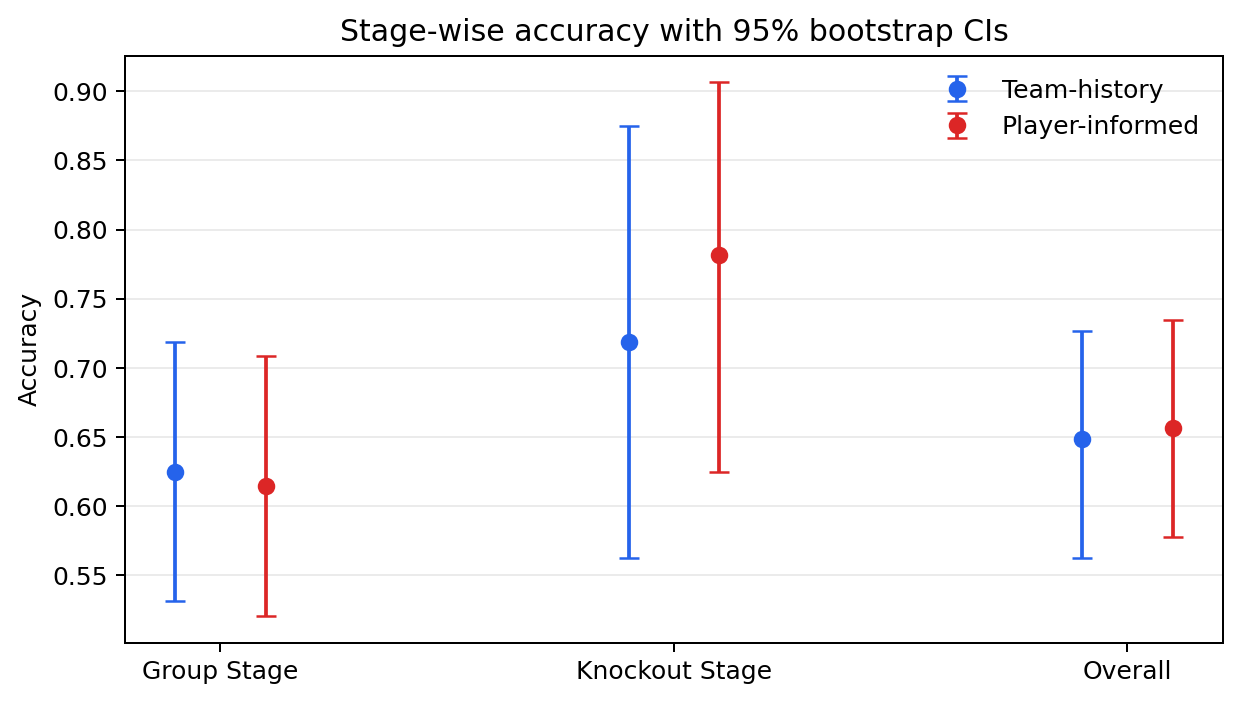

Saved figure: ../../docs/figures/fig2_stage_accuracy_intervals.png


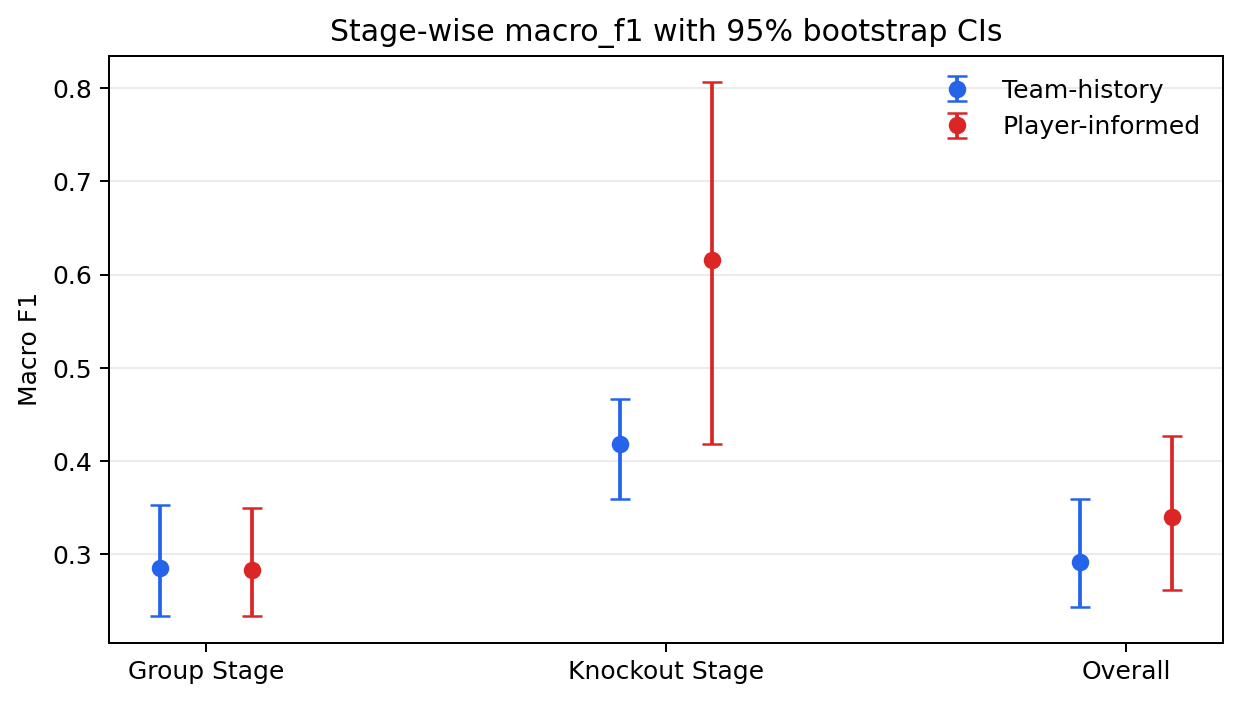

Saved figure: ../../docs/figures/fig_app_stage_macro_f1_intervals.png


In [16]:
# Stage-wise uncertainty (group vs knockout) with figure
stage_uncertainty, stage_differences = bootstrap_metrics(
    holdout,
    model_keys=["team_history", "player_informed"],
    stages=("group_stage", "knockout_stage", "overall"),
)
display(stage_differences.round(3))

colors = {
    "baseline": "#6B7280",
    "team_history": "#2563EB",
    "player_informed": "#DC2626",
}
order = ["group_stage", "knockout_stage", "overall"]

for metric in ["accuracy", "macro_f1"]:
    plot_df = stage_uncertainty[stage_uncertainty["metric"] == metric]
    fig, ax = plt.subplots(figsize=(7, 4))
    for i, mk in enumerate(["team_history", "player_informed"]):
        sub = plot_df[plot_df["model_key"] == mk].set_index("stage").reindex(order)
        x = np.arange(len(order)) + (i - 0.5) * 0.2
        y = sub["point_estimate"].to_numpy()
        ax.errorbar(
            x,
            y,
            yerr=np.vstack(
                [y - sub["ci_low"].to_numpy(), sub["ci_high"].to_numpy() - y]
            ),
            fmt="o",
            capsize=4,
            color=colors[mk],
            label=MODEL_NAMES[mk],
        )
    ax.set_xticks(np.arange(len(order)))
    ax.set_xticklabels([s.replace("_", " ").title() for s in order])
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_title(f"Stage-wise {metric} with 95% bootstrap CIs")
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    filename = (
        "fig2_stage_accuracy_intervals.png"
        if metric == "accuracy"
        else "fig_app_stage_macro_f1_intervals.png"
    )
    save_and_display_fig(fig, filename)

,fav_confederation,model_key,model_name,n,accuracy,ci_low,ci_high
5,CF-1,player_informed,Player-informed,5,0.600,0.200,1.000
0,CF-1,team_history,Team-history,5,0.600,0.200,1.000
6,CF-2,player_informed,Player-informed,7,0.714,0.429,1.000
1,CF-2,team_history,Team-history,7,0.714,0.429,1.000
7,CF-3,player_informed,Player-informed,5,0.200,0.000,0.600
2,CF-3,team_history,Team-history,5,0.400,0.000,0.800
8,CF-4,player_informed,Player-informed,31,0.710,0.548,0.871
3,CF-4,team_history,Team-history,31,0.710,0.548,0.871
9,CF-6,player_informed,Player-informed,80,0.662,0.562,0.762
4,CF-6,team_history,Team-history,80,0.638,0.525,0.738


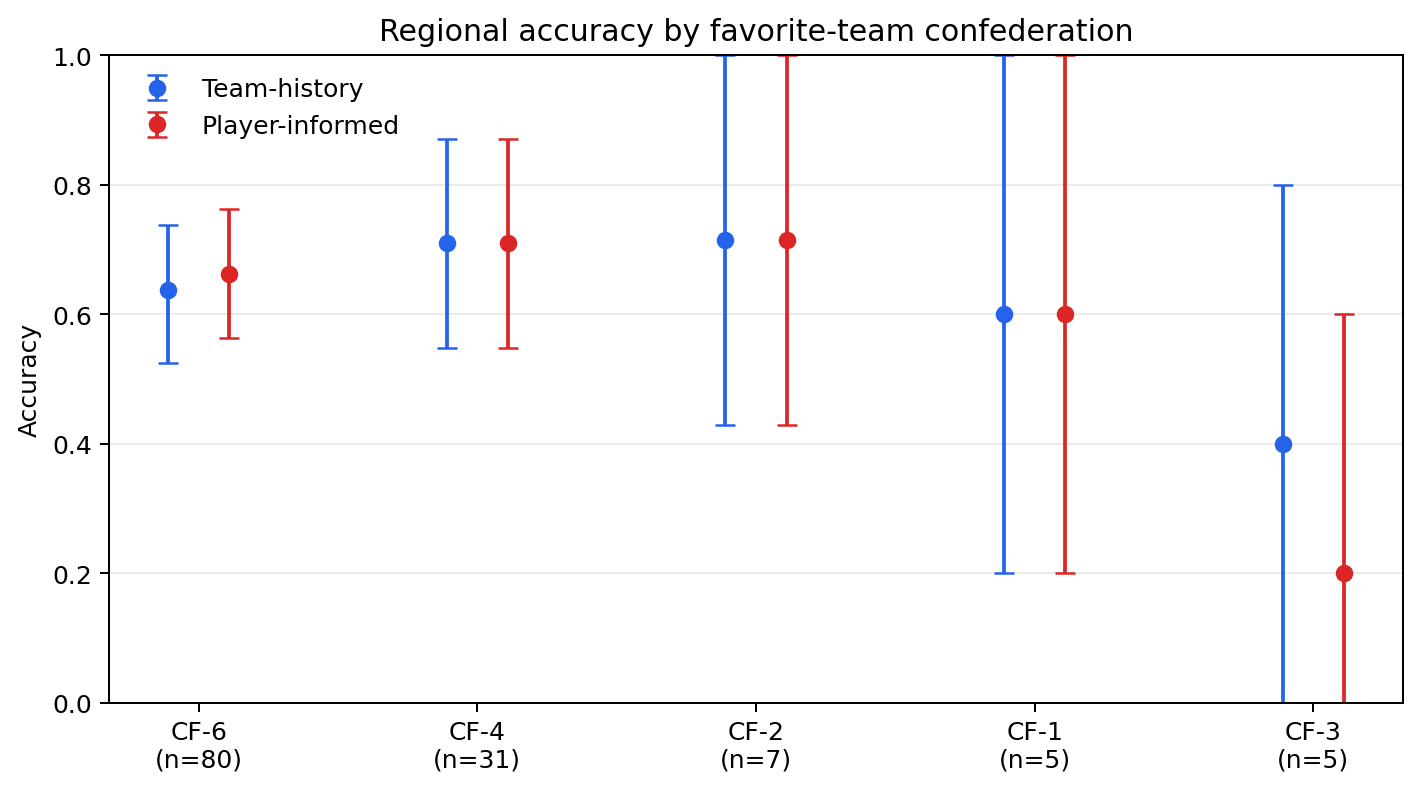

Saved figure: ../../docs/figures/fig3_regional_accuracy_intervals.png


PosixPath('../../docs/figures/fig3_regional_accuracy_intervals.png')

In [ ]:
# Regional reliability by favorite-team confederation (Figure 3)
confed_lookup = teams[["team_id", "confederation_id"]].drop_duplicates()
regional_holdout = holdout.merge(
    confed_lookup.rename(
        columns={"team_id": "fav_team_id", "confederation_id": "fav_confederation"}
    ),
    on="fav_team_id",
    how="left",
)

CONFED_LABELS = {
    "C-AFC": "AFC",
    "C-CAF": "CAF",
    "C-CONCACAF": "CONCACAF",
    "C-CONMEBOL": "CONMEBOL",
    "C-OFC": "OFC",
    "C-UEFA": "UEFA",
}
regional_holdout["fav_confederation"] = (
    regional_holdout["fav_confederation"]
    .map(CONFED_LABELS)
    .fillna(regional_holdout["fav_confederation"])
)


def bootstrap_accuracy_by_group(
    df, model_key, group_col, b=BOOTSTRAP_B, seed=BOOT_SEED
):
    rng = np.random.default_rng(seed)
    rows = []
    for group_value, sub in df.dropna(subset=[group_col]).groupby(group_col):
        idx = np.arange(len(sub))
        n = len(sub)
        samples = []
        for _ in range(b):
            s = sub.iloc[rng.choice(idx, size=n, replace=True)]
            samples.append(accuracy_score(s["y"], s[f"{model_key}_pred"]))
        rows.append(
            {
                group_col: group_value,
                "model_key": model_key,
                "model_name": MODEL_NAMES[model_key],
                "n": n,
                "accuracy": accuracy_score(sub["y"], sub[f"{model_key}_pred"]),
                "ci_low": float(np.percentile(samples, 2.5)),
                "ci_high": float(np.percentile(samples, 97.5)),
            }
        )
    return pd.DataFrame(rows)


regional_accuracy = pd.concat(
    [
        bootstrap_accuracy_by_group(regional_holdout, mk, "fav_confederation")
        for mk in ["team_history", "player_informed"]
    ],
    ignore_index=True,
)
regional_accuracy = regional_accuracy.sort_values(["fav_confederation", "model_key"])
display(regional_accuracy.round(3))

confed_order = (
    regional_accuracy.groupby("fav_confederation")["n"]
    .max()
    .sort_values(ascending=False)
    .index.tolist()
)
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, mk in enumerate(["team_history", "player_informed"]):
    sub = (
        regional_accuracy[regional_accuracy["model_key"] == mk]
        .set_index("fav_confederation")
        .reindex(confed_order)
    )
    x = np.arange(len(confed_order)) + (i - 0.5) * 0.22
    y = sub["accuracy"].to_numpy(dtype=float)
    ax.errorbar(
        x,
        y,
        yerr=np.vstack([y - sub["ci_low"].to_numpy(), sub["ci_high"].to_numpy() - y]),
        fmt="o",
        capsize=4,
        color=colors[mk],
        label=MODEL_NAMES[mk],
    )
labels = [
    f"{confed}\n(n={int(regional_accuracy[regional_accuracy['fav_confederation'] == confed]['n'].max())})"
    for confed in confed_order
]
ax.set_xticks(np.arange(len(confed_order)))
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("Regional accuracy by favorite-team confederation")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
save_and_display_fig(fig, "fig3_regional_accuracy_intervals.png")

##### **Section 8 - Temporal Leakage Audit**

- Leave-one-tournament-out (LOTO) CV has temporal leakage: when the held-out fold is an early tournament, future tournaments enter training. 

- Here, we document which folds are affected and run an expanding-window (forward-chaining) sensitivity check as a leakage-safe alternative.

In [18]:
# LOTO leakage audit: which folds train on future tournaments
all_years = sorted(df_fav["year"].dropna().astype(int).unique())

leakage_rows = []
for model_key, cfg in FINAL_CONFIGS.items():
    pre_holdout = [
        y for y in all_years if cfg["train_min_year"] <= y and y not in HOLDOUT_YEARS
    ]
    for heldout_year in pre_holdout:
        loto_train = [y for y in pre_holdout if y != heldout_year]
        future = [y for y in loto_train if y > heldout_year]
        past = [y for y in loto_train if y < heldout_year]
        leakage_rows.append(
            {
                "model_name": cfg["display_name"],
                "heldout_year": heldout_year,
                "uses_future_tournaments": bool(future),
                "future_train_years": ",".join(map(str, future)),
                "past_train_years": ",".join(map(str, past)),
                "forward_chaining_possible": bool(past),
            }
        )

leakage_audit = pd.DataFrame(leakage_rows)
display(leakage_audit)

leakage_summary = (
    leakage_audit.groupby("model_name")["uses_future_tournaments"]
    .agg(folds_using_future="sum", total_folds="count")
    .reset_index()
)
display(leakage_summary)

,model_name,heldout_year,uses_future_tournaments,future_train_years,past_train_years,forward_chaining_possible
0,Baseline,2006,True,"2010,2014",,False
1,Baseline,2010,True,2014,2006,True
2,Baseline,2014,False,,"2006,2010",True
3,Team-history,1998,True,"2002,2006,2010,2014",,False
4,Team-history,2002,True,"2006,2010,2014",1998,True
5,Team-history,2006,True,"2010,2014","1998,2002",True
6,Team-history,2010,True,2014,"1998,2002,2006",True
7,Team-history,2014,False,,"1998,2002,2006,2010",True
8,Player-informed,2006,True,"2010,2014",,False
9,Player-informed,2010,True,2014,2006,True


,model_name,folds_using_future,total_folds
0,Baseline,2,3
1,Player-informed,2,3
2,Team-history,4,5


,model_name,test_year,n_train,n_test,accuracy,macro_f1
0,Baseline,2010,64,64,0.641,0.263
1,Baseline,2014,128,64,0.703,0.275
6,Player-informed,2010,64,64,0.531,0.362
7,Player-informed,2014,128,64,0.688,0.380
2,Team-history,2002,64,64,0.578,0.324
3,Team-history,2006,128,64,0.594,0.248
4,Team-history,2010,192,64,0.656,0.307
5,Team-history,2014,256,64,0.719,0.281


,model_key,model_name,n_folds,total_test_matches,mean_accuracy,weighted_accuracy,mean_macro_f1,weighted_macro_f1
0,baseline,Baseline,2,128,0.672,0.672,0.269,0.269
1,player_informed,Player-informed,2,128,0.609,0.609,0.371,0.371
2,team_history,Team-history,4,256,0.637,0.637,0.290,0.290


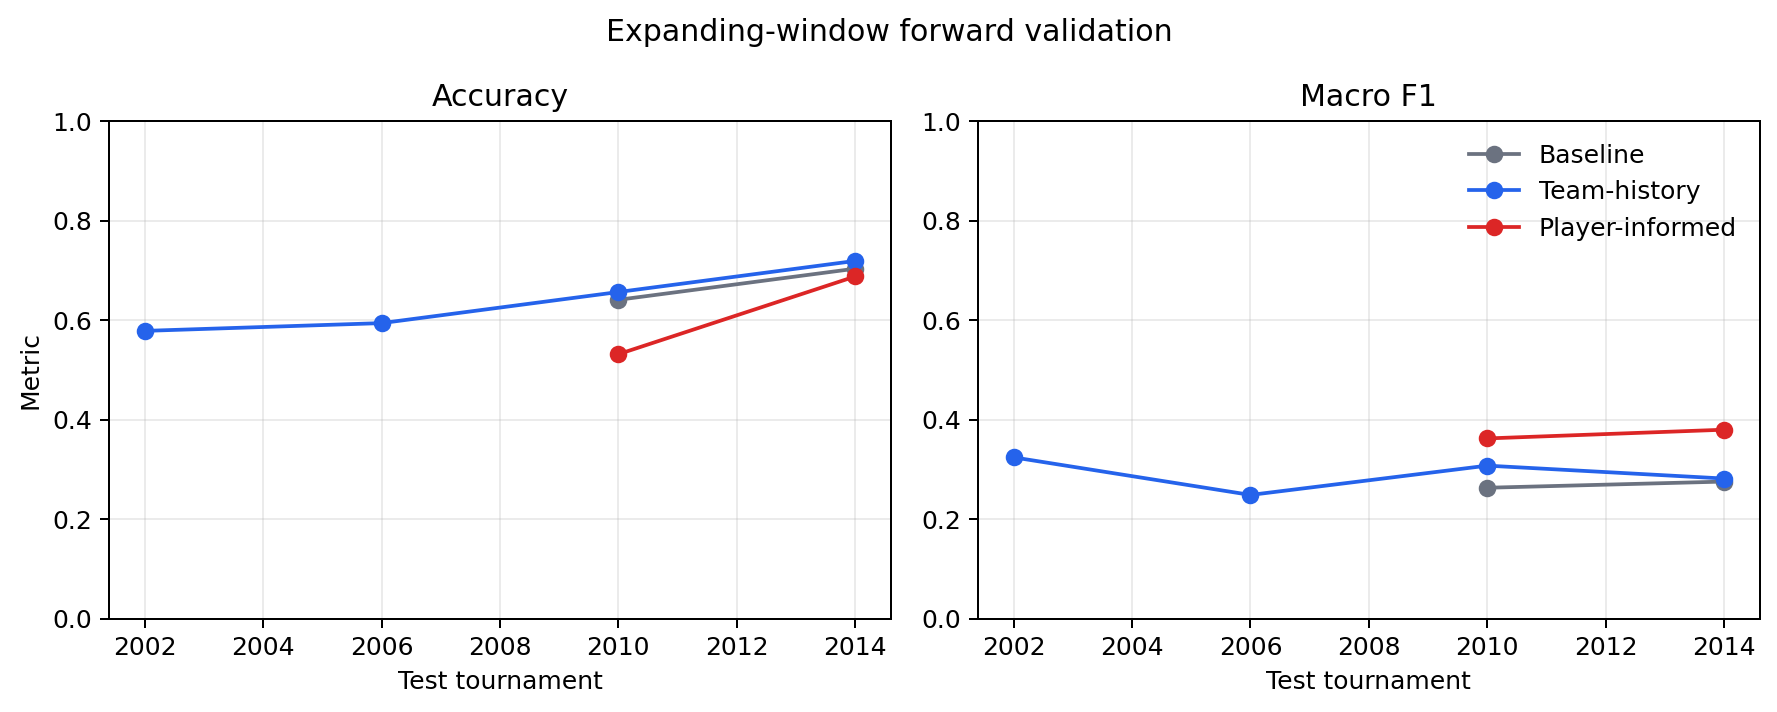

Saved figure: ../../docs/figures/fig_app_expanding_window_forward_validation.png


PosixPath('../../docs/figures/fig_app_expanding_window_forward_validation.png')

In [19]:
# Expanding-window forward validation helper
def fit_predict_years(model_key, train_years, test_years):
    cfg = FINAL_CONFIGS[model_key]
    train = df_fav[df_fav["year"].isin(train_years)].copy()
    test = df_fav[df_fav["year"].isin(test_years)].copy()
    if train.empty or test.empty:
        raise ValueError(f"Empty split for {model_key}")
    m = clone(cfg["pipeline"])
    m.fit(train[cfg["features"]], train["y"])
    pred = m.predict(test[cfg["features"]])
    return {
        "model_key": model_key,
        "model_name": cfg["display_name"],
        "train_years": ",".join(map(str, sorted(train_years))),
        "test_year": int(test_years[0]),
        "n_train": len(train),
        "n_test": len(test),
        "accuracy": float(accuracy_score(test["y"], pred)),
        "macro_f1": float(f1_score(test["y"], pred, average="macro", zero_division=0)),
    }


# Run expanding-window over all available pre-holdout tournaments
forward_rows = []
for model_key, cfg in FINAL_CONFIGS.items():
    eligible = [
        y for y in all_years if cfg["train_min_year"] <= y and y not in HOLDOUT_YEARS
    ]
    for test_year in eligible:
        train_years = [y for y in eligible if y < test_year]
        if not train_years:
            continue
        forward_rows.append(fit_predict_years(model_key, train_years, [test_year]))

forward_folds = pd.DataFrame(forward_rows)
forward_summary_ew = (
    forward_folds.groupby(["model_key", "model_name"])
    .agg(
        n_folds=("accuracy", "size"),
        total_test_matches=("n_test", "sum"),
        mean_accuracy=("accuracy", "mean"),
        weighted_accuracy=(
            "accuracy",
            lambda s: np.average(s, weights=forward_folds.loc[s.index, "n_test"]),
        ),
        mean_macro_f1=("macro_f1", "mean"),
        weighted_macro_f1=(
            "macro_f1",
            lambda s: np.average(s, weights=forward_folds.loc[s.index, "n_test"]),
        ),
    )
    .reset_index()
)

display(
    forward_folds[
        ["model_name", "test_year", "n_train", "n_test", "accuracy", "macro_f1"]
    ]
    .sort_values(["model_name", "test_year"])
    .round(3)
)
display(forward_summary_ew.round(3))

# Figure: fold-level metrics per test year
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
for ax, metric in zip(axes, ["accuracy", "macro_f1"]):
    for mk in MODEL_KEYS:
        sub = forward_folds[forward_folds["model_key"] == mk].sort_values("test_year")
        ax.plot(
            sub["test_year"],
            sub[metric],
            marker="o",
            color=colors[mk],
            label=MODEL_NAMES[mk],
        )
    ax.set_title(metric.replace("_", " ").title())
    ax.set_ylim(0, 1)
    ax.set_xlabel("Test tournament")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("Metric")
axes[1].legend(frameon=False)
fig.suptitle("Expanding-window forward validation")
fig.tight_layout()
save_and_display_fig(fig, "fig_app_expanding_window_forward_validation.png")

##### **Section 9 - Consolidated Validation Summary**

- Primary evidence: models trained through 2014, evaluated on pooled 2018 + 2022 holdout (128 matches). 

- Expanding-window forward validation confirms rankings are stable across leakage-safe temporal splits. 

- Majority-favorite baseline = 66.4%.

In [20]:
# Context baselines on pooled holdout
majority_fav_acc = float((holdout["y"] == 2).sum() / len(holdout))
draw_rate = float((holdout["y"] == 1).sum() / len(holdout))
upset_rate = float((holdout["y"] == 0).sum() / len(holdout))
print(f"Majority-favorite baseline accuracy : {majority_fav_acc:.3f}")
print(f"Draw rate                           : {draw_rate:.3f}")
print(f"Upset rate (fav loses)              : {upset_rate:.3f}")

# Per-year diagnostic
year_rows = []
for year, sub in holdout.groupby("year"):
    for mk in MODEL_KEYS:
        year_rows.append(
            {
                "year": int(year),
                "model_name": MODEL_NAMES[mk],
                "n": len(sub),
                "accuracy": accuracy_score(sub["y"], sub[f"{mk}_pred"]),
                "macro_f1": f1_score(
                    sub["y"], sub[f"{mk}_pred"], average="macro", zero_division=0
                ),
            }
        )
year_diag = pd.DataFrame(year_rows)
display(year_diag.round(3))

# Primary holdout + expanding-window side-by-side
consol_rows = []
acc_unc = overall_uncertainty[overall_uncertainty["metric"] == "accuracy"].set_index(
    "model_key"
)
f1_unc = overall_uncertainty[overall_uncertainty["metric"] == "macro_f1"].set_index(
    "model_key"
)
ew_sum = forward_summary_ew.set_index("model_key")

for mk in MODEL_KEYS:
    consol_rows.append(
        {
            "Model": MODEL_NAMES[mk],
            "Holdout acc": f"{table1_df.loc[mk,'holdout_accuracy']:.3f}"
            f" [{acc_unc.loc[mk,'ci_low']:.3f}, {acc_unc.loc[mk,'ci_high']:.3f}]",
            "Holdout F1": f"{table1_df.loc[mk,'holdout_macro_f1']:.3f}"
            f" [{f1_unc.loc[mk,'ci_low']:.3f}, {f1_unc.loc[mk,'ci_high']:.3f}]",
            "EW mean acc": (
                f"{ew_sum.loc[mk,'mean_accuracy']:.3f}" if mk in ew_sum.index else "n/a"
            ),
            "EW mean F1": (
                f"{ew_sum.loc[mk,'mean_macro_f1']:.3f}" if mk in ew_sum.index else "n/a"
            ),
        }
    )
consol_df = pd.DataFrame(consol_rows)
print("\nConsolidated validation summary (95% bootstrap CI in brackets):")
display(consol_df)

Majority-favorite baseline accuracy : 0.664
Draw rate                           : 0.148
Upset rate (fav loses)              : 0.188


,year,model_name,n,accuracy,macro_f1
0,2018,Baseline,64,0.688,0.274
1,2018,Team-history,64,0.656,0.264
2,2018,Player-informed,64,0.688,0.367
3,2022,Baseline,64,0.625,0.256
4,2022,Team-history,64,0.641,0.320
5,2022,Player-informed,64,0.625,0.310



Consolidated validation summary (95% bootstrap CI in brackets):


,Model,Holdout acc,Holdout F1,EW mean acc,EW mean F1
0,Baseline,"0.656 [0.570, 0.734]","0.265 [0.244, 0.284]",0.672,0.269
1,Team-history,"0.648 [0.562, 0.727]","0.292 [0.246, 0.361]",0.637,0.290
2,Player-informed,"0.656 [0.570, 0.734]","0.340 [0.261, 0.434]",0.609,0.371


#### **Part IV - Interpretation & Robustness**

##### **Section 10 - Feature Importance (SHAP + LIME)**

- Global SHAP beeswarm on the player-informed XGBoost model (top 15 features). 

- Followed by 1–2 LIME local explanations for representative matches.

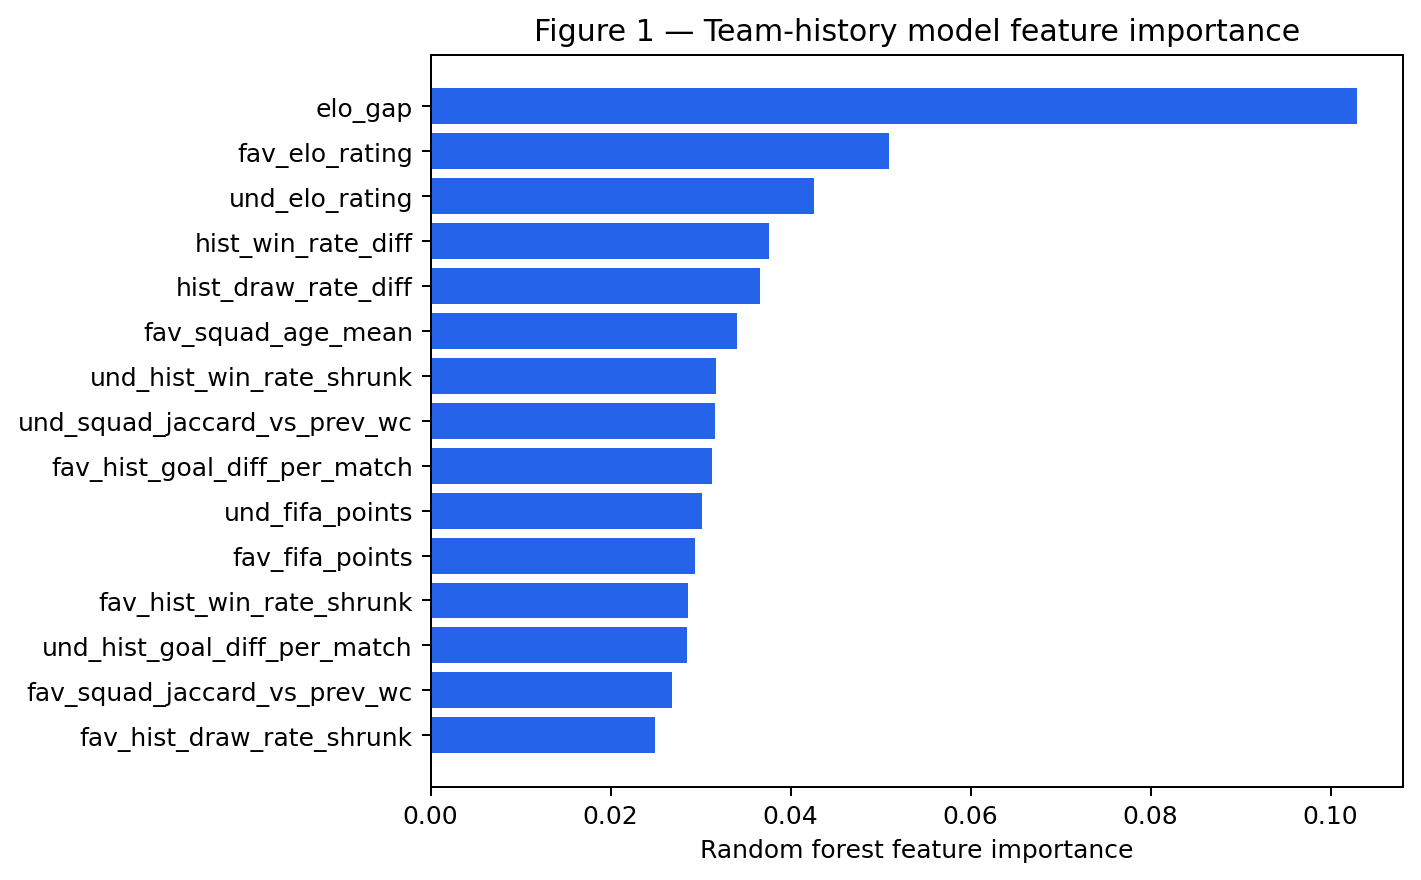

Saved figure: ../../docs/figures/fig1_team_history_feature_importance.png


,feature,importance
0,elo_gap,0.102910
1,fav_elo_rating,0.050902
2,und_elo_rating,0.042618
3,hist_win_rate_diff,0.037643
4,hist_draw_rate_diff,0.036600
5,fav_squad_age_mean,0.034052
6,und_hist_win_rate_shrunk,0.031736
7,und_squad_jaccard_vs_prev_wc,0.031608
8,fav_hist_goal_diff_per_match,0.031242
9,und_fifa_points,0.030196


In [ ]:
# Figure 1: team-history model feature importance
th_model = results["team_history"]["fitted_model"]
th_feats = FINAL_CONFIGS["team_history"]["features"]
th_clf = th_model.named_steps["clf"]

team_history_importance = pd.DataFrame(
    {"feature": th_feats, "importance": th_clf.feature_importances_}
).sort_values("importance", ascending=False)

top_n = min(15, len(team_history_importance))
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    team_history_importance["feature"].head(top_n)[::-1],
    team_history_importance["importance"].head(top_n)[::-1],
    color="#2563EB",
)
ax.set_xlabel("Random forest feature importance")
ax.set_title("Figure 1 — Team-history model feature importance")
fig.tight_layout()
save_and_display_fig(fig, "fig1_team_history_feature_importance.png")
display(team_history_importance.head(15).reset_index(drop=True))

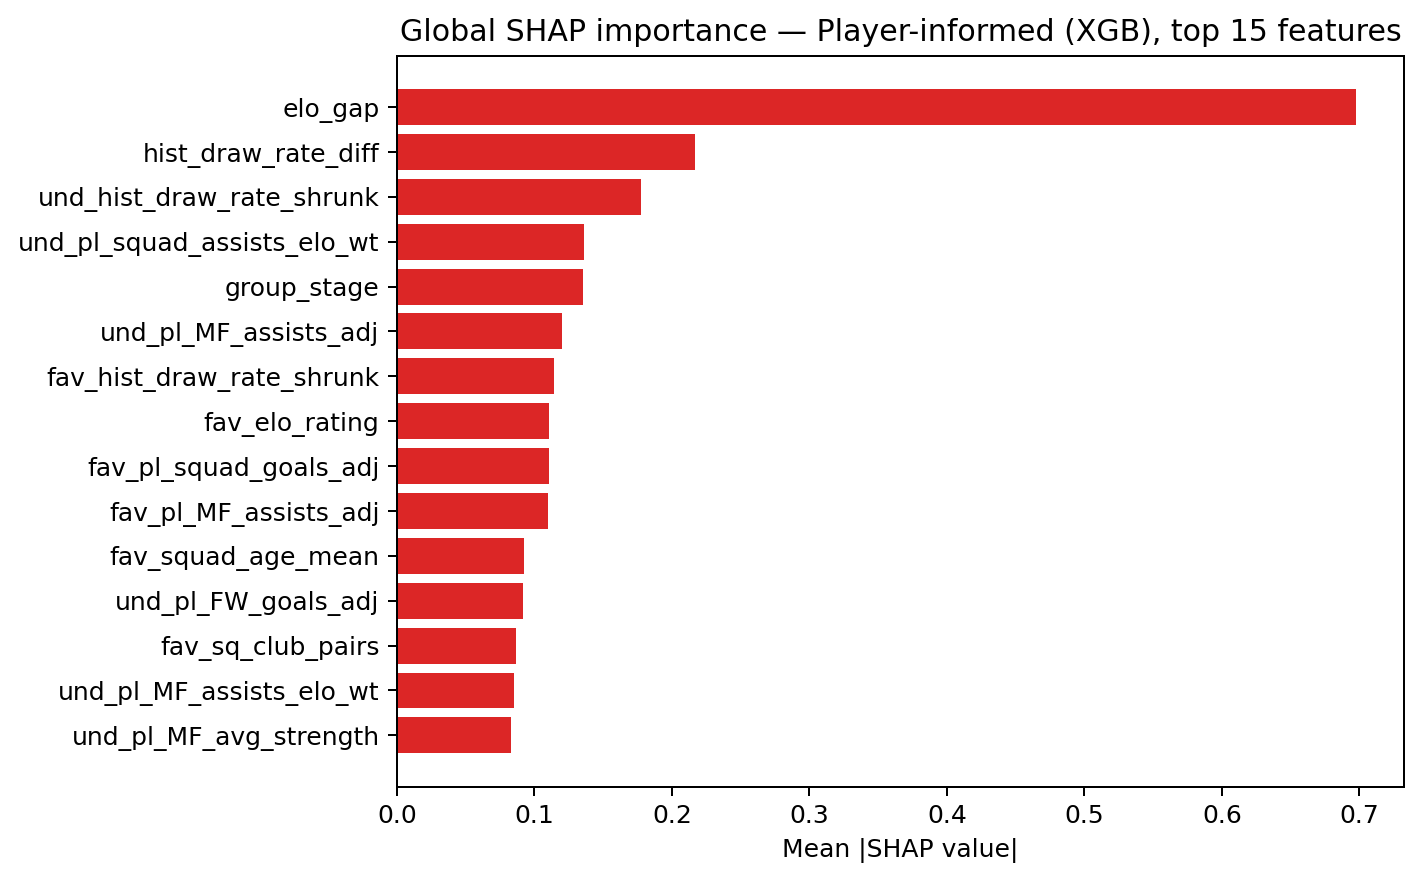

Saved figure: ../../docs/figures/fig_app_player_informed_shap_importance.png


,feature,mean_abs_shap
0,elo_gap,0.697912
1,hist_draw_rate_diff,0.217100
2,und_hist_draw_rate_shrunk,0.177340
3,und_pl_squad_assists_elo_wt,0.135845
4,group_stage,0.135614
5,und_pl_MF_assists_adj,0.120171
6,fav_hist_draw_rate_shrunk,0.114031
7,fav_elo_rating,0.110690
8,fav_pl_squad_goals_adj,0.110561
9,fav_pl_MF_assists_adj,0.110125


In [ ]:
# SHAP contributions on player-informed model
pe_model = results["player_informed"]["fitted_model"]
pe_feats = FINAL_CONFIGS["player_informed"]["features"]
pe_imp = pe_model.named_steps["imp"]
pe_clf = pe_model.named_steps["clf"]

train_pe = df_fav[
    (df_fav["year"] >= FINAL_CONFIGS["player_informed"]["train_min_year"])
    & (~df_fav["year"].isin(HOLDOUT_YEARS))
].copy()
X_train_np = pe_imp.transform(train_pe[pe_feats])
holdout_feature_frame = results["player_informed"]["holdout_pred"][["match_id"]].merge(
    df_fav[["match_id"] + pe_feats], on="match_id", how="left"
)
X_ho_np = pe_imp.transform(holdout_feature_frame[pe_feats].fillna(0))


def _xgb_native_shap_values(model, X):
    contribs = model.get_booster().predict(xgb.DMatrix(X), pred_contribs=True)
    if contribs.ndim == 3:
        if contribs.shape[1] == len(CLASS_LABELS):
            return [contribs[:, k, :-1] for k in range(contribs.shape[1])]
        return [contribs[:, :-1, k] for k in range(contribs.shape[2])]
    if contribs.ndim == 2:
        return [contribs[:, :-1]]
    raise ValueError(f"Unexpected SHAP contribution shape: {contribs.shape}")


shap_values = _xgb_native_shap_values(pe_clf, X_train_np)

# Mean |SHAP| across all classes
mean_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
shap_df = pd.DataFrame({"feature": pe_feats, "mean_abs_shap": mean_shap})
shap_df = shap_df.sort_values("mean_abs_shap", ascending=False)

# Bar chart — top 15
top_n = min(15, len(shap_df))
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    shap_df["feature"].head(top_n)[::-1],
    shap_df["mean_abs_shap"].head(top_n)[::-1],
    color="#DC2626",
)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Global SHAP importance — Player-informed (XGB), top 15 features")
fig.tight_layout()
save_and_display_fig(fig, "fig_app_player_informed_shap_importance.png")

display(shap_df.head(15).reset_index(drop=True))

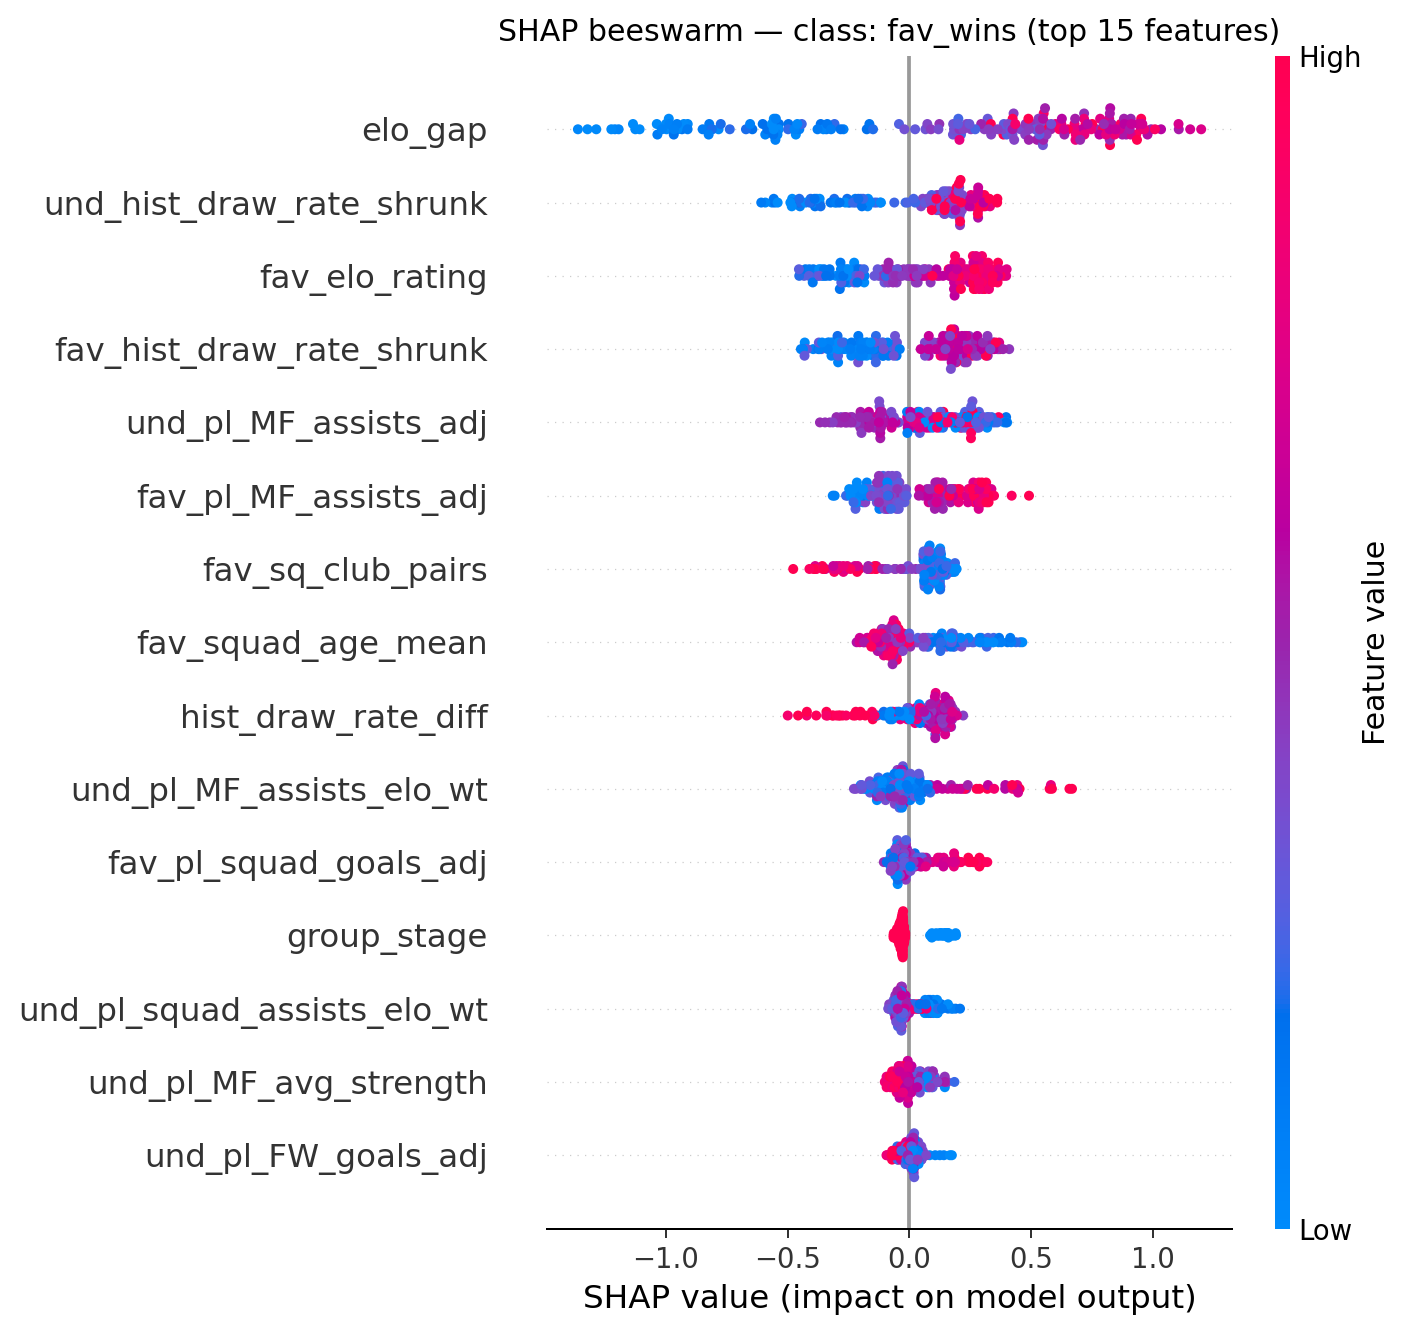

Saved figure: ../../docs/figures/fig_app_player_informed_shap_beeswarm_fav_wins.png


PosixPath('../../docs/figures/fig_app_player_informed_shap_beeswarm_fav_wins.png')

In [23]:
# SHAP beeswarm — top 15 features, fav_wins class (class index 2)
top_feats = shap_df["feature"].head(15).tolist()
feat_idx = [pe_feats.index(f) for f in top_feats]
sv_favwins = shap_values[2][:, feat_idx]
xv_favwins = X_train_np[:, feat_idx]

plt.figure(figsize=(8, 5))
shap.summary_plot(
    sv_favwins, xv_favwins, feature_names=top_feats, show=False, plot_type="dot"
)
fig = plt.gcf()
ax = plt.gca()
ax.set_title("SHAP beeswarm — class: fav_wins (top 15 features)")
fig.tight_layout()
save_and_display_fig(fig, "fig_app_player_informed_shap_beeswarm_fav_wins.png")

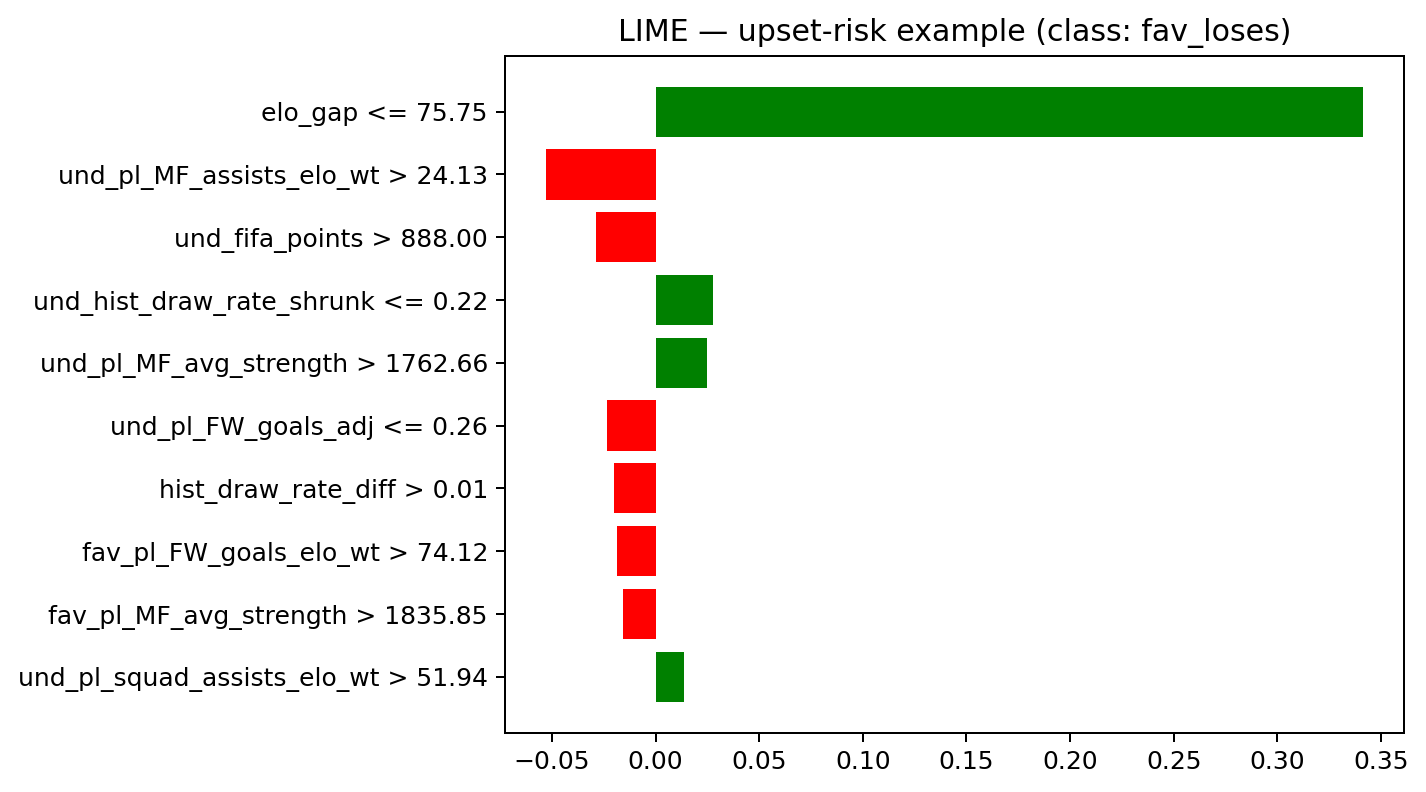

Saved figure: ../../docs/figures/fig_app_lime_upset_risk.png


,feature_rule,weight
0,elo_gap <= 75.75,0.341507
1,und_pl_MF_assists_elo_wt > 24.13,-0.052747
2,und_fifa_points > 888.00,-0.028564
3,und_hist_draw_rate_shrunk <= 0.22,0.027910
4,und_pl_MF_avg_strength > 1762.66,0.024736
5,und_pl_FW_goals_adj <= 0.26,-0.023322
6,hist_draw_rate_diff > 0.01,-0.020095
7,fav_pl_FW_goals_elo_wt > 74.12,-0.018647
8,fav_pl_MF_avg_strength > 1835.85,-0.015530
9,und_pl_squad_assists_elo_wt > 51.94,0.013951


,value
match_id,M-2018-62
year,2018
fav_team,England
und_team,Croatia
y,0
pred,0
prob_fav_loses,0.766635
prob_draw,0.02133
prob_fav_wins,0.212035


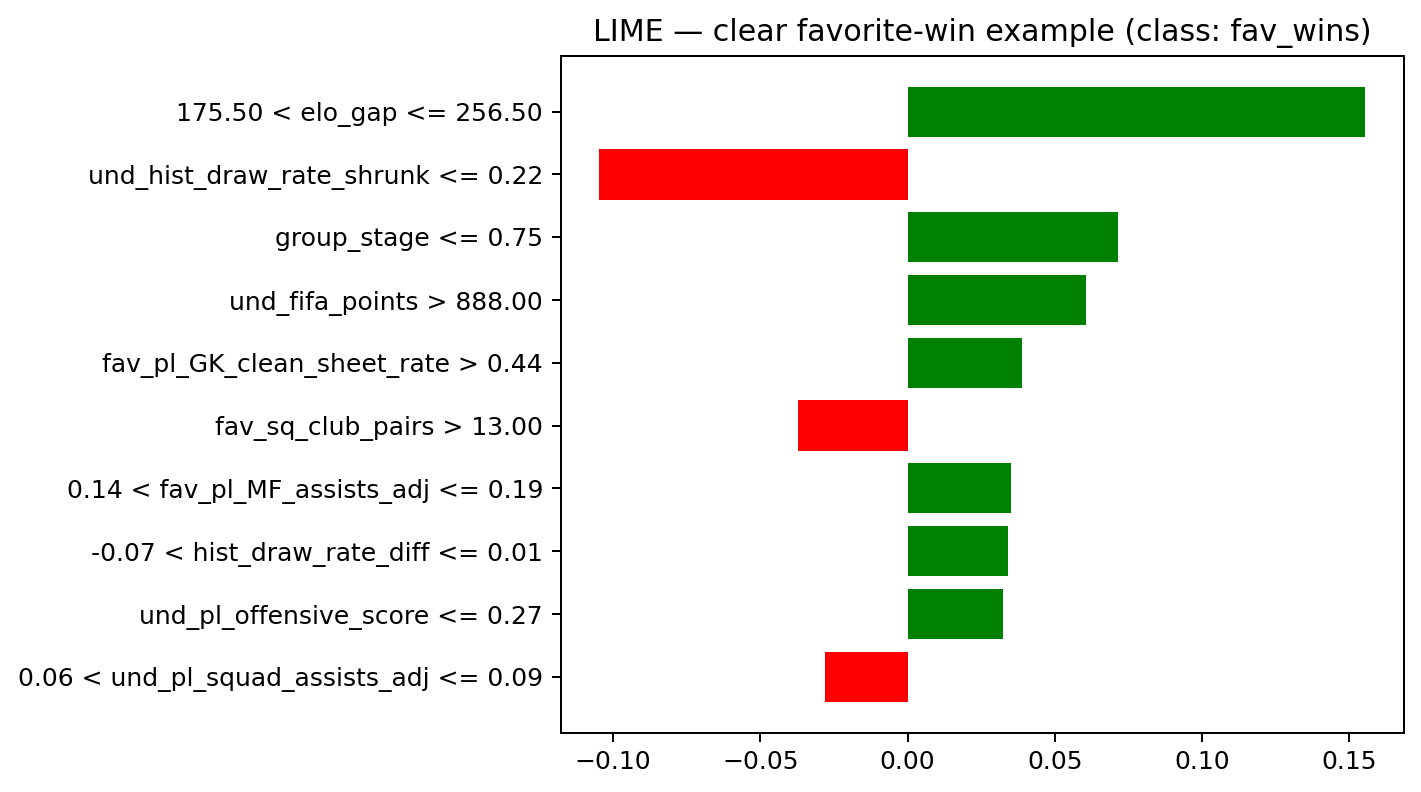

Saved figure: ../../docs/figures/fig_app_lime_clear_favorite_win.png


,feature_rule,weight
0,175.50 < elo_gap <= 256.50,0.155430
1,und_hist_draw_rate_shrunk <= 0.22,-0.104870
2,group_stage <= 0.75,0.071481
3,und_fifa_points > 888.00,0.060429
4,fav_pl_GK_clean_sheet_rate > 0.44,0.038955
5,fav_sq_club_pairs > 13.00,-0.037214
6,0.14 < fav_pl_MF_assists_adj <= 0.19,0.034945
7,-0.07 < hist_draw_rate_diff <= 0.01,0.034037
8,und_pl_offensive_score <= 0.27,0.032381
9,0.06 < und_pl_squad_assists_adj <= 0.09,-0.027964


,value
match_id,M-2022-49
year,2022
fav_team,Netherlands
und_team,United States
y,2
pred,2
prob_fav_loses,0.001535
prob_draw,0.001441
prob_fav_wins,0.997024


In [ ]:
# LIME local explanations for 2 representative holdout matches
if HAS_LIME:
    ho_pred = results["player_informed"]["holdout_pred"].copy()
    ho_pred["fav_team"] = ho_pred["fav_team_id"].map(team_name_map2)
    ho_pred["und_team"] = ho_pred["und_team_id"].map(team_name_map2)
    ho_feat = ho_pred[["match_id"]].merge(
        df_fav[["match_id"] + pe_feats], on="match_id", how="left"
    )
    X_ho_imp = pe_imp.transform(ho_feat[pe_feats])

    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_np,
        feature_names=pe_feats,
        class_names=CLASS_LABELS,
        mode="classification",
        discretize_continuous=True,
        random_state=SEED,
    )

    def render_lime_case(row_idx, class_idx, title, filename):
        pos = ho_pred.index.get_loc(row_idx)
        exp = explainer_lime.explain_instance(
            X_ho_imp[pos], pe_clf.predict_proba, num_features=10, labels=[class_idx]
        )
        fig = exp.as_pyplot_figure(label=class_idx)
        fig.set_size_inches(8, 4.5)
        fig.axes[0].set_title(title)
        fig.tight_layout()
        save_and_display_fig(fig, filename)
        lime_table = pd.DataFrame(
            exp.as_list(label=class_idx), columns=["feature_rule", "weight"]
        )
        display(lime_table)
        case = ho_pred.loc[
            row_idx,
            [
                "match_id",
                "year",
                "fav_team",
                "und_team",
                "y",
                "pred",
                "prob_fav_loses",
                "prob_draw",
                "prob_fav_wins",
            ],
        ]
        display(case.to_frame("value"))

    # Case 1: upset-risk example (actual=fav_loses, highest model P(fav_loses)).
    upsets = ho_pred[ho_pred["y"] == 0]
    if not upsets.empty:
        best_upset_idx = upsets["prob_fav_loses"].idxmax()
        render_lime_case(
            best_upset_idx,
            0,
            "LIME — upset-risk example (class: fav_loses)",
            "fig_app_lime_upset_risk.png",
        )

    # Case 2: clear favorite-win example (actual=fav_wins, highest P(fav_wins)).
    fav_wins = ho_pred[ho_pred["y"] == 2]
    if not fav_wins.empty:
        clearest_idx = fav_wins["prob_fav_wins"].idxmax()
        render_lime_case(
            clearest_idx,
            2,
            "LIME — clear favorite-win example (class: fav_wins)",
            "fig_app_lime_clear_favorite_win.png",
        )
else:
    print("LIME not installed — skipping local explanations. Run: pip install lime")

##### **Section 11 - Algorithm Sensitivity**

- The original design confounds feature set with algorithm: baseline/team-history use RF while player-informed uses XGBoost.

- This section isolates the effect by running all three models under (a) unified XGBoost and (b) unified RF, and compares holdout metrics and bootstrap pairwise differences.

In [25]:
from sklearn.ensemble import RandomForestClassifier as _RFC

SHARED_XGB_PARAMS = dict(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=SEED,
    verbosity=0,
    n_jobs=-1,
)
SHARED_RF_PARAMS = dict(
    n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1
)


def _make_pipe(algo):
    clf = (
        xgb.XGBClassifier(**SHARED_XGB_PARAMS)
        if algo == "xgb"
        else _RFC(**SHARED_RF_PARAMS)
    )
    return Pipeline([("imp", SimpleImputer()), ("clf", clf)])


UNIFIED_CFGS = {
    "baseline": {"train_min_year": 2006, "features": TEAM_ONLY_FEATURES},
    "team_history": {"train_min_year": 1998, "features": TEAM_ONLY_FEATURES},
    "player_informed": {"train_min_year": 2006, "features": PLAYER_INFORMED_FEATURES},
}


def run_unified(algo_name):
    res = {}
    for mk, cfg in UNIFIED_CFGS.items():
        train = df_fav[
            (df_fav["year"] >= cfg["train_min_year"])
            & (~df_fav["year"].isin(HOLDOUT_YEARS))
        ].copy()
        ho = df_fav[df_fav["year"].isin(HOLDOUT_YEARS)].copy()
        m = clone(_make_pipe(algo_name))
        m.fit(train[cfg["features"]], train["y"])
        pred = m.predict(ho[cfg["features"]])
        prob = m.predict_proba(ho[cfg["features"]])
        ho = ho[["match_id", "year", "y", "group_stage", "knockout_stage"]].copy()
        ho["pred"] = pred
        for j, lbl in enumerate(["prob_fav_loses", "prob_draw", "prob_fav_wins"]):
            ho[lbl] = prob[:, j]
        res[mk] = {
            "pred_df": ho,
            "acc": float(accuracy_score(ho["y"], pred)),
            "f1": float(f1_score(ho["y"], pred, average="macro", zero_division=0)),
        }
        print(
            f"  [{algo_name}] {MODEL_NAMES[mk]:20s}  acc={res[mk]['acc']:.3f}  F1={res[mk]['f1']:.3f}"
        )
    return res


print("Unified XGBoost:")
results_xgb_u = run_unified("xgb")
print("\nUnified RF:")
results_rf_u = run_unified("rf")

Unified XGBoost:


  [xgb] Baseline              acc=0.617  F1=0.302


  [xgb] Team-history          acc=0.602  F1=0.369


  [xgb] Player-informed       acc=0.656  F1=0.340

Unified RF:


  [rf] Baseline              acc=0.656  F1=0.265


  [rf] Team-history          acc=0.648  F1=0.292


  [rf] Player-informed       acc=0.664  F1=0.266


In [26]:
# Three-way comparison table: original vs unified XGB vs unified RF
three_way_rows = []
for mk in MODEL_KEYS:
    three_way_rows.append(
        {
            "Model": MODEL_NAMES[mk],
            "Orig algo": "RF" if mk != "player_informed" else "XGB",
            "Orig acc": round(table1_df.loc[mk, "holdout_accuracy"], 3),
            "Orig F1": round(table1_df.loc[mk, "holdout_macro_f1"], 3),
            "Unified XGB acc": round(results_xgb_u[mk]["acc"], 3),
            "Unified XGB F1": round(results_xgb_u[mk]["f1"], 3),
            "Unified RF acc": round(results_rf_u[mk]["acc"], 3),
            "Unified RF F1": round(results_rf_u[mk]["f1"], 3),
        }
    )
display(pd.DataFrame(three_way_rows).set_index("Model"))

,Orig algo,Orig acc,Orig F1,Unified XGB acc,Unified XGB F1,Unified RF acc,Unified RF F1
Model,,,,,,,
Baseline,RF,0.656,0.265,0.617,0.302,0.656,0.265
Team-history,RF,0.648,0.292,0.602,0.369,0.648,0.292
Player-informed,XGB,0.656,0.340,0.656,0.340,0.664,0.266


In [37]:
# Bootstrap pairwise: player_informed vs team_history under unified RF
def bootstrap_pairwise_simple(
    res_dict,
    hi="player_informed",
    lo="team_history",
    stage_col=None,
    b=BOOTSTRAP_B,
    seed=SEED,
):
    hi_df = res_dict[hi]["pred_df"].copy()
    lo_df = res_dict[lo]["pred_df"].copy()
    merged = hi_df[["match_id", "y", "group_stage", "knockout_stage", "pred"]].rename(
        columns={"pred": "hi_pred"}
    )
    merged = merged.merge(
        lo_df[["match_id", "pred"]].rename(columns={"pred": "lo_pred"}), on="match_id"
    )
    if stage_col:
        merged = merged[merged[stage_col].fillna(0).astype(bool)].copy()
    idx = np.arange(len(merged))
    n = len(merged)
    rng = np.random.default_rng(seed)
    d_acc, d_f1 = [], []
    for _ in range(b):
        s = merged.iloc[rng.choice(idx, size=n, replace=True)]
        d_acc.append(
            accuracy_score(s["y"], s["hi_pred"]) - accuracy_score(s["y"], s["lo_pred"])
        )
        d_f1.append(
            f1_score(s["y"], s["hi_pred"], average="macro", zero_division=0)
            - f1_score(s["y"], s["lo_pred"], average="macro", zero_division=0)
        )

    def ci(v):
        v = np.array(v)
        return (
            float(np.mean(v)),
            float(np.percentile(v, 2.5)),
            float(np.percentile(v, 97.5)),
        )

    pt_acc = accuracy_score(merged["y"], merged["hi_pred"]) - accuracy_score(
        merged["y"], merged["lo_pred"]
    )
    pt_f1 = f1_score(
        merged["y"], merged["hi_pred"], average="macro", zero_division=0
    ) - f1_score(merged["y"], merged["lo_pred"], average="macro", zero_division=0)
    return {
        "n": n,
        "pt_acc": pt_acc,
        "ci_acc": ci(d_acc),
        "pt_f1": pt_f1,
        "ci_f1": ci(d_f1),
    }


def fmt_ci(pt, lo, hi):
    return f"{pt:+.3f} [{lo:+.3f}, {hi:+.3f}]"


bs_rf_rows = []
for stage_label, stage_col in [
    ("group_stage", "group_stage"),
    ("knockout_stage", "knockout_stage"),
    ("overall", None),
]:
    r = bootstrap_pairwise_simple(results_rf_u, stage_col=stage_col)
    ma, ca = r["pt_acc"], r["ci_acc"]
    mf, cf = r["pt_f1"], r["ci_f1"]
    sig_acc = "CI excludes 0" if (ca[1] > 0 or ca[2] < 0) else "CI includes 0"
    sig_f1 = "CI excludes 0" if (cf[1] > 0 or cf[2] < 0) else "CI includes 0"
    bs_rf_rows.append(
        {
            "stage": stage_label,
            "n": r["n"],
            "Δ accuracy [95% CI]": fmt_ci(ma, ca[1], ca[2]),
            "acc note": sig_acc,
            "Δ macro-F1 [95% CI]": fmt_ci(mf, cf[1], cf[2]),
            "f1 note": sig_f1,
        }
    )

print("Bootstrap pairwise — player_informed vs team_history (unified RF):")
display(pd.DataFrame(bs_rf_rows))

# Verdict: does player-feature F1 advantage hold under unified RF?
pe_f1_rf = results_rf_u["player_informed"]["f1"]
th_f1_rf = results_rf_u["team_history"]["f1"]
print(
    f"\nPlayer-informed F1 ({pe_f1_rf:.3f}) >= Team-history F1 ({th_f1_rf:.3f}): {pe_f1_rf >= th_f1_rf}"
)

Bootstrap pairwise — player_informed vs team_history (unified RF):


,stage,n,Δ accuracy [95% CI],acc note,Δ macro-F1 [95% CI],f1 note
0,group_stage,96,"+0.021 [-0.021, +0.062]",CI includes 0,"-0.024 [-0.091, +0.015]",CI includes 0
1,knockout_stage,32,"+0.000 [+0.000, +0.000]",CI includes 0,"+0.000 [+0.000, +0.000]",CI includes 0
2,overall,128,"+0.016 [-0.016, +0.047]",CI includes 0,"-0.026 [-0.090, +0.011]",CI includes 0



Player-informed F1 (0.266) >= Team-history F1 (0.292): False


Key finding: player-feature advantage is a feature–algorithm interaction (XGB needed).